In [8]:
import os
import pandas as pd

ROOT = "../social_signal"
activity_dirs = sorted([d for d in os.listdir(ROOT) if os.path.isdir(os.path.join(ROOT, d))])

print("\n=== Checking subject coverage per activity ===")
activity_id_sets = {}

for activity in activity_dirs:
    activity_dir = os.path.join(ROOT, activity)
    csv_files = sorted([f for f in os.listdir(activity_dir) if f.endswith(".csv")])
    ids = []
    for f in csv_files:
        try:
            num = int(''.join(filter(str.isdigit, f.split('_')[-1].replace('.csv', ''))))
            ids.append(num)
        except:
            pass
    if ids:
        activity_id_sets[activity] = set(ids)
        print(f"{activity:20s} → {len(ids):4d} subjects | ID range: {min(ids)}–{max(ids)}")
    else:
        print(f"[WARN] {activity} — No valid IDs found.")

# ✅ 全体受试者集合
all_ids = set.union(*activity_id_sets.values())
print(f"\nTotal unique subjects across all activities: {len(all_ids)}")



=== Checking subject coverage per activity ===
breathingNormally    →  744 subjects | ID range: 0–743
coughing             →  723 subjects | ID range: 0–722
hyperventilation     →  725 subjects | ID range: 0–724
other                → 2408 subjects | ID range: 0–2407

Total unique subjects across all activities: 2408


=== Loading feature_activity/other_features.csv ===
Loaded 274027 rows
Aggregated to 2408 files
Clustering into 4 groups ...


c:\Users\ROG666\anaconda3\envs\Mobile\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\ROG666\anaconda3\envs\Mobile\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(


✅ Saved cluster results → feature_activity/other_file_clusters_k4.csv


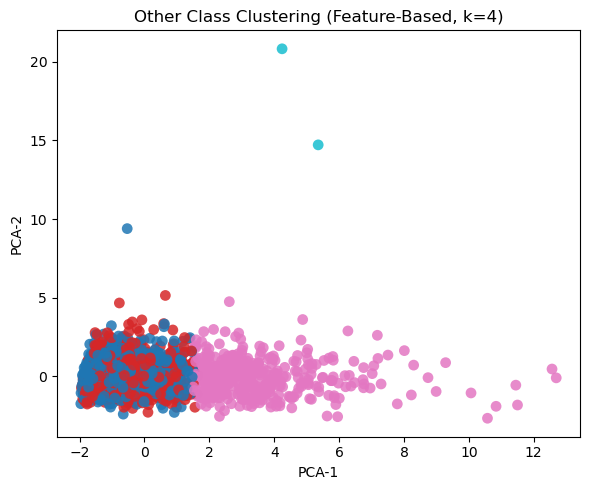

✅ Cluster plot saved to: feature_activity\other_clusters_k4.png

=== Cluster Summary ===
   Cluster  Count  Percent
0        0    955    39.66
1        1   1047    43.48
2        2    404    16.78
3        3      2     0.08

=== Cluster Evaluation ===
Silhouette Score : 0.1842  (越高越好, ~0.25以上才算明显分离)
Davies-Bouldin   : 1.3476  (越低越好)


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ============================================================
# 🔹 路径配置
# ============================================================
INPUT_FILE = "feature_activity/other_features.csv"
OUTPUT_DIR = "feature_activity"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"=== Loading {INPUT_FILE} ===")
df = pd.read_csv(INPUT_FILE)
print(f"Loaded {len(df)} rows")

# ============================================================
# 🔹 特征选择
# ============================================================
feat_cols = [
    'jerk_rms', 'breathing_stability', 'rhythm_stability',
    'burst_density', 'energy_burst_ratio', 'breathing_intensity_var',
    'fft_energy', 'zero_cross_rate', 'dominant_resp_freq'
]

if not set(feat_cols).issubset(df.columns):
    raise ValueError(f"Missing required feature columns in {INPUT_FILE}")

# 每个 SourceFile 聚合为一个样本
df_feat = df.groupby("SourceFile")[feat_cols].mean()
print(f"Aggregated to {len(df_feat)} files")

# ============================================================
# 🔹 KMeans 聚类（指定为 4 类）
# ============================================================
scaler = StandardScaler()
X = scaler.fit_transform(df_feat)

n_clusters = 4  # ← 你已确定 other 类有 4 种动作
print(f"Clustering into {n_clusters} groups ...")
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X)

df_feat["Cluster"] = labels
df_feat.to_csv(os.path.join(OUTPUT_DIR, "other_file_clusters_k4.csv"))
print("✅ Saved cluster results → feature_activity/other_file_clusters_k4.csv")

# ============================================================
# 🔹 PCA 降维 + 可视化（仅颜色区分类别）
# ============================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(
    X_pca[:,0], X_pca[:,1],
    c=labels, cmap='tab10', s=60, alpha=0.85, edgecolors='none'
)
plt.title("Other Class Clustering (Feature-Based, k=4)")
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, "other_clusters_k4.png")
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"✅ Cluster plot saved to: {plot_path}")

# ============================================================
# 🔹 聚类统计表
# ============================================================
stats = df_feat["Cluster"].value_counts().sort_index().reset_index()
stats.columns = ["Cluster", "Count"]
stats["Percent"] = (stats["Count"] / stats["Count"].sum() * 100).round(2)
print("\n=== Cluster Summary ===")
print(stats)
stats.to_csv(os.path.join(OUTPUT_DIR, "other_cluster_stats_k4.csv"), index=False)

from sklearn.metrics import silhouette_score, davies_bouldin_score

sil = silhouette_score(X, labels)
db = davies_bouldin_score(X, labels)
print(f"\n=== Cluster Evaluation ===")
print(f"Silhouette Score : {sil:.4f}  (越高越好, ~0.25以上才算明显分离)")
print(f"Davies-Bouldin   : {db:.4f}  (越低越好)")



=== Loading feature_activity/other_features.csv ===
Loaded 274027 rows
Aggregated to 2408 files
Clustering into 3 groups ...
✅ Saved cluster results → feature_activity/other_file_clusters_k4.csv


c:\Users\ROG666\anaconda3\envs\Mobile\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\ROG666\anaconda3\envs\Mobile\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(


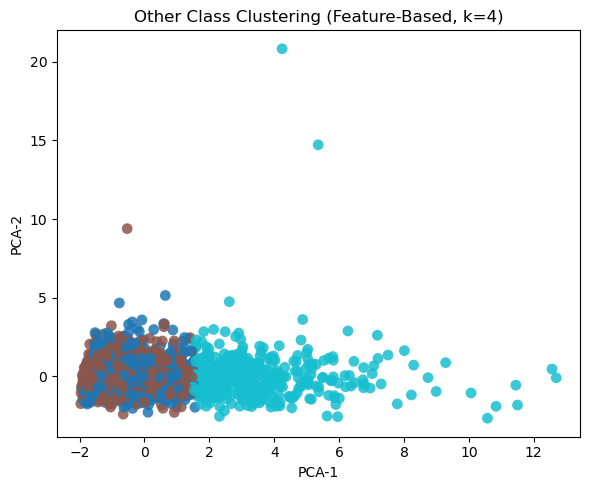

✅ Cluster plot saved to: feature_activity\other_clusters_k4.png

=== Cluster Summary ===
   Cluster  Count  Percent
0        0   1047    43.48
1        1    955    39.66
2        2    406    16.86

=== Cluster Evaluation ===
Silhouette Score : 0.1793  (越高越好, ~0.25以上才算明显分离)
Davies-Bouldin   : 1.6885  (越低越好)


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ============================================================
# 🔹 路径配置
# ============================================================
INPUT_FILE = "feature_activity/other_features.csv"
OUTPUT_DIR = "feature_activity"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"=== Loading {INPUT_FILE} ===")
df = pd.read_csv(INPUT_FILE)
print(f"Loaded {len(df)} rows")

# ============================================================
# 🔹 特征选择
# ============================================================
feat_cols = [
    'jerk_rms', 'breathing_stability', 'rhythm_stability',
    'burst_density', 'energy_burst_ratio', 'breathing_intensity_var',
    'fft_energy', 'zero_cross_rate', 'dominant_resp_freq'
]

if not set(feat_cols).issubset(df.columns):
    raise ValueError(f"Missing required feature columns in {INPUT_FILE}")

# 每个 SourceFile 聚合为一个样本
df_feat = df.groupby("SourceFile")[feat_cols].mean()
print(f"Aggregated to {len(df_feat)} files")

# ============================================================
# 🔹 KMeans 聚类（指定为 4 类）
# ============================================================
scaler = StandardScaler()
X = scaler.fit_transform(df_feat)

n_clusters = 3  # ← 你已确定 other 类有 4 种动作
print(f"Clustering into {n_clusters} groups ...")
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X)

df_feat["Cluster"] = labels
df_feat.to_csv(os.path.join(OUTPUT_DIR, "other_file_clusters_k4.csv"))
print("✅ Saved cluster results → feature_activity/other_file_clusters_k4.csv")

# ============================================================
# 🔹 PCA 降维 + 可视化（仅颜色区分类别）
# ============================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(
    X_pca[:,0], X_pca[:,1],
    c=labels, cmap='tab10', s=60, alpha=0.85, edgecolors='none'
)
plt.title("Other Class Clustering (Feature-Based, k=4)")
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, "other_clusters_k4.png")
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"✅ Cluster plot saved to: {plot_path}")

# ============================================================
# 🔹 聚类统计表
# ============================================================
stats = df_feat["Cluster"].value_counts().sort_index().reset_index()
stats.columns = ["Cluster", "Count"]
stats["Percent"] = (stats["Count"] / stats["Count"].sum() * 100).round(2)
print("\n=== Cluster Summary ===")
print(stats)
stats.to_csv(os.path.join(OUTPUT_DIR, "other_cluster_stats_k4.csv"), index=False)

from sklearn.metrics import silhouette_score, davies_bouldin_score

sil = silhouette_score(X, labels)
db = davies_bouldin_score(X, labels)
print(f"\n=== Cluster Evaluation ===")
print(f"Silhouette Score : {sil:.4f}  (越高越好, ~0.25以上才算明显分离)")
print(f"Davies-Bouldin   : {db:.4f}  (越低越好)")



=== Loading feature_activity/other_features.csv ===
Loaded 274027 rows
Aggregated to 2408 files
Clustering into 2 groups ...
Saved cluster results → .\other_file_clusters_k2.csv


c:\Users\ROG666\anaconda3\envs\Mobile\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(


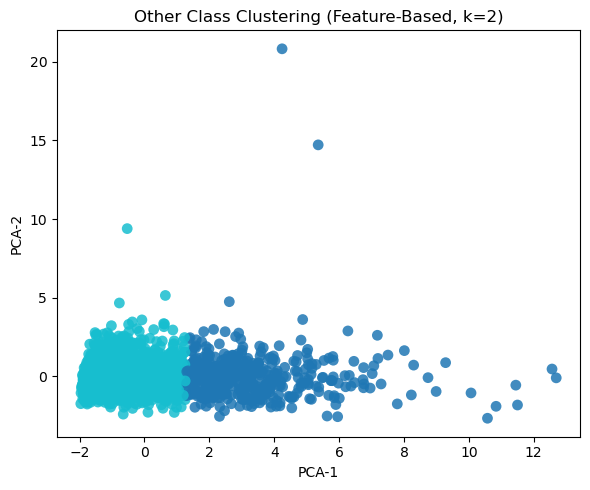

Cluster plot saved to: .\other_clusters_k2.png

=== Cluster Summary ===
   Cluster  Count  Percent
0        0    443     18.4
1        1   1965     81.6
Saved cluster summary → .\other_cluster_stats_k2.csv

=== Cluster Evaluation ===
Silhouette Score : 0.4336  (越高越好, ~0.25以上算明显分离)
Davies-Bouldin   : 1.2677  (越低越好)

Clustering complete! All outputs saved in current directory.


In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

# ============================================================
# 🔹 路径配置
# ============================================================
INPUT_FILE = "feature_activity/other_features.csv"
OUTPUT_DIR = "."  # 当前目录
print(f"=== Loading {INPUT_FILE} ===")
df = pd.read_csv(INPUT_FILE)
print(f"Loaded {len(df)} rows")

# ============================================================
# 🔹 特征选择
# ============================================================
feat_cols = [
    'jerk_rms', 'breathing_stability', 'rhythm_stability',
    'burst_density', 'energy_burst_ratio', 'breathing_intensity_var',
    'fft_energy', 'zero_cross_rate', 'dominant_resp_freq'
]

if not set(feat_cols).issubset(df.columns):
    raise ValueError(f"Missing required feature columns in {INPUT_FILE}")

# 每个 SourceFile 聚合为一个样本
df_feat = df.groupby("SourceFile")[feat_cols].mean()
print(f"Aggregated to {len(df_feat)} files")

# ============================================================
# 🔹 KMeans 聚类（k=2）
# ============================================================
scaler = StandardScaler()
X = scaler.fit_transform(df_feat)

n_clusters = 2
print(f"Clustering into {n_clusters} groups ...")
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X)

df_feat["Cluster"] = labels
cluster_csv_path = os.path.join(OUTPUT_DIR, "other_file_clusters_k2.csv")
df_feat.to_csv(cluster_csv_path)
print(f"Saved cluster results → {cluster_csv_path}")

# ============================================================
# 🔹 PCA 降维 + 可视化
# ============================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(
    X_pca[:,0], X_pca[:,1],
    c=labels, cmap='tab10', s=60, alpha=0.85, edgecolors='none'
)
plt.title("Other Class Clustering (Feature-Based, k=2)")
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")
plt.tight_layout()

plot_path = os.path.join(OUTPUT_DIR, "other_clusters_k2.png")
plt.savefig(plot_path, dpi=300)
plt.show()
print(f"Cluster plot saved to: {plot_path}")

# ============================================================
# 🔹 聚类统计表
# ============================================================
stats = df_feat["Cluster"].value_counts().sort_index().reset_index()
stats.columns = ["Cluster", "Count"]
stats["Percent"] = (stats["Count"] / stats["Count"].sum() * 100).round(2)
print("\n=== Cluster Summary ===")
print(stats)
stats_path = os.path.join(OUTPUT_DIR, "other_cluster_stats_k2.csv")
stats.to_csv(stats_path, index=False)
print(f"Saved cluster summary → {stats_path}")

# ============================================================
# 🔹 聚类评估指标
# ============================================================
sil = silhouette_score(X, labels)
db = davies_bouldin_score(X, labels)
print(f"\n=== Cluster Evaluation ===")
print(f"Silhouette Score : {sil:.4f}  (越高越好, ~0.25以上算明显分离)")
print(f"Davies-Bouldin   : {db:.4f}  (越低越好)")

print("\nClustering complete! All outputs saved in current directory.")


c:\Users\ROG666\anaconda3\envs\Mobile\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(
c:\Users\ROG666\anaconda3\envs\Mobile\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(
c:\Users\ROG666\anaconda3\envs\Mobile\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=10.
  warnings.warn(
c:\Users\ROG666\anaconda3\envs\Mobile\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserW

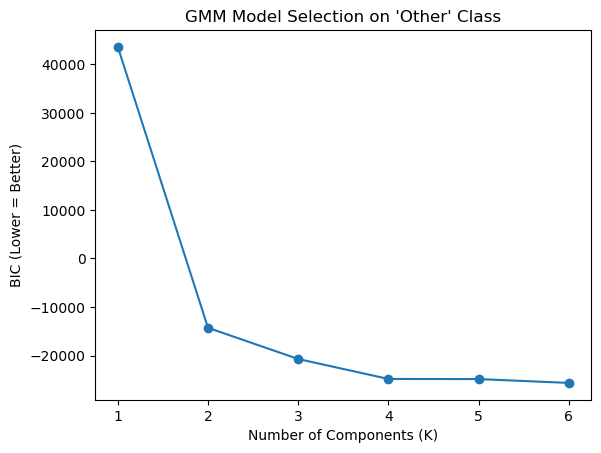

In [2]:
from sklearn.mixture import GaussianMixture
import numpy as np

# GMM 模型选择（基于 BIC）
n_candidates = range(1, 7)
bics = []
for k in n_candidates:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X)
    bics.append(gmm.bic(X))

plt.plot(n_candidates, bics, '-o')
plt.xlabel("Number of Components (K)")
plt.ylabel("BIC (Lower = Better)")
plt.title("GMM Model Selection on 'Other' Class")
plt.show()


In [9]:
import os
import pandas as pd

OUTPUT_DIR = "merged_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def normalize_accel_columns(df: pd.DataFrame) -> pd.DataFrame:
    cols_lower = {c.lower(): c for c in df.columns}
    x_name = cols_lower.get("accelx") or cols_lower.get("accel_x")
    y_name = cols_lower.get("accely") or cols_lower.get("accel_y")
    z_name = cols_lower.get("accelz") or cols_lower.get("accel_z")
    renames = {x_name: "accelX", y_name: "accelY", z_name: "accelZ"}
    return df.rename(columns=renames)[["accelX", "accelY", "accelZ"]].astype(float)


# ✅ Step 1: 收集每个活动下的所有受试者 ID
id_sets = []
for activity in activity_dirs:
    csv_files = [f for f in os.listdir(os.path.join(ROOT, activity)) if f.endswith(".csv")]
    ids = []
    for f in csv_files:
        try:
            ids.append(int(''.join(filter(str.isdigit, f.split('_')[-1].replace('.csv','')))))
        except:
            pass
    id_sets.append(set(ids))

# ✅ Step 2: 不取交集，而取并集
all_ids = sorted(list(set.union(*id_sets)))
print(f"共发现 {len(all_ids)} 名受试者（所有活动总计）")

# ✅ Step 3: 遍历每个活动，合并所有受试者（不再过滤）
for activity in activity_dirs:
    activity_dir = os.path.join(ROOT, activity)
    csv_files = [f for f in os.listdir(activity_dir) if f.endswith(".csv")]
    if not csv_files:
        print(f"[WARN] {activity} 没有 CSV 文件。")
        continue

    print(f"\nMerging category: {activity}")
    activity_dfs = []
    for fn in sorted(csv_files):
        fpath = os.path.join(activity_dir, fn)
        try:
            df = pd.read_csv(fpath)
            df = normalize_accel_columns(df)
            
            # --- 限制 "other" 类样本 ---
            if activity.lower() == "other":
                df = df.sample(frac=0.3, random_state=42).reset_index(drop=True)
            
            df["Activity"] = activity
            df["SourceFile"] = fn
            activity_dfs.append(df)
        except Exception as e:
            print(f"[ERROR] 读取 {fpath} 失败: {e}")


    if not activity_dfs:
        print(f"[WARN] {activity} 没有可合并的数据。")
        continue

    merged_activity = pd.concat(activity_dfs, ignore_index=True)
    out_path = os.path.join(OUTPUT_DIR, f"merged_{activity}.csv")
    merged_activity.to_csv(out_path, index=False)
    print(f"{activity} merged {len(csv_files)} files → {out_path}")

print("\n✅ 所有活动已合并（包含全部受试者）。")
print("输出目录:", OUTPUT_DIR)
print("生成文件列表:", sorted(os.listdir(OUTPUT_DIR)))


共发现 2408 名受试者（所有活动总计）

Merging category: breathingNormally
breathingNormally merged 744 files → merged_data\merged_breathingNormally.csv

Merging category: coughing
coughing merged 723 files → merged_data\merged_coughing.csv

Merging category: hyperventilation
hyperventilation merged 725 files → merged_data\merged_hyperventilation.csv

Merging category: other
other merged 2408 files → merged_data\merged_other.csv

✅ 所有活动已合并（包含全部受试者）。
输出目录: merged_data
生成文件列表: ['abnormal_summary.csv', 'merged_breathingNormally.csv', 'merged_coughing.csv', 'merged_hyperventilation.csv', 'merged_other.csv']


In [17]:
import os
import numpy as np
import pandas as pd
from scipy.signal import welch

INPUT_DIR = "merged_data"
OUTPUT_DIR = "feature_activity"
os.makedirs(OUTPUT_DIR, exist_ok=True)


def add_lightweight_features(df, alpha=0.98, eps=1e-8, win=20):
    """
    === Lightweight SSC Feature Extraction (Leakage-Free + Cough Enhanced) ===
    新增特征：
    - cough_energy_ratio：短时突发能量 / 长时能量
    - breathing_disruption：呼吸稳定性急降指数（检测节律断裂）
    - spectral_sharpness：高频能量集中度（检测咳嗽频谱尖峰）
    - short_energy_ratio：短期能量相对占比（捕捉弱咳嗽）
    
    该版本主要增强了对 NaN 值的处理和鲁棒性。
    """

    if 'SourceFile' not in df.columns:
        raise ValueError("Missing 'SourceFile' column.")

    aligned_segments = []

    # === 🌬️ 快速主导频率函数（替代滚动 Welch） ===
    def dominant_freq_fast(sig, fs=12.5, win_len=64, step=10):
        # 1. 安全处理 NaN
        sig = pd.Series(sig).ffill().bfill().to_numpy()
        n = len(sig)
        dom_freq = np.zeros(n)
        
        # 2. 避免在稀疏数据上插值
        if n < win_len:
             # 如果序列太短，跳过计算，返回全零 (或 NaN，取决于后续处理)
             return dom_freq

        for i in range(0, n, step):
            seg = sig[max(0, i - win_len): i]
            
            # 确保有足够的数据进行 FFT
            if len(seg) < 16 or np.std(seg) < eps:
                continue
                
            f = np.fft.rfftfreq(len(seg), 1/fs)
            Pxx = np.abs(np.fft.rfft(seg)) ** 2
            
            # 专注于呼吸频带（0.1Hz 到 2.0Hz）
            mask = (f >= 0.1) & (f <= 2.0)
            if np.any(mask):
                dom_freq[i] = f[mask][np.argmax(Pxx[mask])]
        
        # 3. 统一插值和填充
        # 用前一个有效值填充，如果开头是 0，则用 0 填充
        dom_freq = pd.Series(dom_freq).replace(0, np.nan).ffill().fillna(0).to_numpy()
        
        return np.clip(dom_freq, 0, 2.0)

    for _, gdf in df.groupby('SourceFile'):
        a_orig = gdf[['accelX', 'accelY', 'accelZ']].to_numpy(float)
        n = len(a_orig)
        if n < 3:
            continue
            
        # ⚠️ 修复 NaN/Inf：在开始计算前处理原始信号
        a = a_orig.copy()
        a[np.isinf(a)] = np.nan
        # 使用前向/后向填充处理原始数据中的 NaN
        a = pd.DataFrame(a).ffill().bfill().to_numpy()


        # === 1️⃣ EMA 重力估计 ===
        g = np.zeros_like(a)
        # 使用第一段的均值进行初始化，避免 NaN
        g[0] = np.mean(a[:min(win, n)], axis=0) if n > 0 else np.zeros(3)
        for i in range(1, n):
            g[i] = alpha * g[i - 1] + (1 - alpha) * a[i]
            
        lin = a - g
        jerk = np.vstack([np.zeros(3), np.diff(a, axis=0)])

        accelMag = np.linalg.norm(a, axis=1)
        linAccMag = np.linalg.norm(lin, axis=1)
        jerkMag = np.linalg.norm(jerk, axis=1)
        a_vert = a[:, 2]
        
        # 将 NumPy 数组转换为 Series，便于滚动计算和填充
        accelMag_series = pd.Series(accelMag)
        linAccMag_series = pd.Series(linAccMag)
        jerkMag_series = pd.Series(jerkMag)
        a_vert_series = pd.Series(a_vert)

        # === 2️⃣ 滚动能量特征 ===
        jerk_rms = jerkMag_series.rolling(win, min_periods=1).apply(
            lambda x: np.sqrt(np.mean(x ** 2)), raw=True
        ).ffill().fillna(0).to_numpy() # 填充 0

        breathing_stability = 1 - a_vert_series.rolling(win, min_periods=1).std().ffill().fillna(1.0).to_numpy()
        breathing_stability = np.clip(breathing_stability, 0, 1)
        
        diffs = np.abs(a_vert_series.diff().fillna(0))
        rhythm_stability = 1 - diffs.rolling(win, min_periods=1).mean().ffill().fillna(1.0).to_numpy()
        rhythm_stability = np.clip(rhythm_stability, 0, 1)

        # === 3️⃣ 咳嗽爆发密度 ===
        local_mean = jerkMag_series.rolling(win*2, min_periods=10).mean().ffill().fillna(eps)
        local_std = jerkMag_series.rolling(win*2, min_periods=10).std().ffill().fillna(eps)
        thr = local_mean + 2.5 * local_std
        peaks = (jerkMag_series > thr).astype(float)
        burst_density = peaks.rolling(win, min_periods=1).mean().ffill().fillna(0).to_numpy()
        burst_density = np.clip(burst_density, 0, 1)

        # === 4️⃣ 呼吸强度变化 ===
        local_mean_lin = linAccMag_series.rolling(win*2, min_periods=10).mean().ffill().fillna(eps)
        energy_burst_ratio = np.clip(linAccMag_series / local_mean_lin, 0, 10).to_numpy()
        
        breathing_intensity_var = linAccMag_series.rolling(win*2, min_periods=10).std().ffill().fillna(eps)
        local_max_var = breathing_intensity_var.rolling(win*2, min_periods=10).max().ffill().fillna(eps)
        breathing_intensity_var = np.clip(breathing_intensity_var / local_max_var, 0, 1).to_numpy()

        # === 5️⃣ FFT + 高频集中度 ===
        fs = 12.5
        win_fft = 64
        
        fft_energy = accelMag_series.rolling(win_fft, min_periods=10).apply(
            lambda x: np.sum(np.abs(np.fft.rfft(x))**2) if len(x) >= 16 else np.nan, raw=True
        ).ffill().fillna(eps)
        fft_local_max = fft_energy.rolling(win_fft, min_periods=10).max().ffill().fillna(eps)
        fft_norm = np.clip(fft_energy / fft_local_max, 0, 1).to_numpy()
        
        # Zero Crossing Rate (ZCR)
        zcr = ((np.sign(a_vert_series) != np.sign(a_vert_series.shift(1))).astype(float)
               .rolling(win_fft, min_periods=2).mean().ffill().fillna(0).to_numpy())
        zcr = np.clip(zcr, 0, 1)

        # === 🌬️ 主导呼吸频率 ===
        resp_freq = dominant_freq_fast(a_vert, fs=fs, win_len=64, step=10)

        # === ✅ 新增咳嗽增强特征 ===
        # (1) Cough Energy Ratio
        short_win, long_win = 5, 50
        short_energy = jerkMag_series.rolling(short_win, min_periods=1).mean().ffill().fillna(eps)
        long_energy = jerkMag_series.rolling(long_win, min_periods=10).mean().ffill().fillna(eps)
        cough_energy_ratio = np.clip(short_energy / long_energy, 0, 10).to_numpy()

        # (2) Breathing Disruption Index
        b_stab = pd.Series(breathing_stability)
        # 计算急剧下降的次数
        breathing_disruption = (b_stab.diff().fillna(0) < -0.05).rolling(10, min_periods=1).sum()
        breathing_disruption = np.clip(breathing_disruption / 10.0, 0, 1).to_numpy()

        # (3) Spectral Sharpness
        def safe_spectral_sharpness(x):
            if len(x) < 16 or np.std(x) < eps: return 0.0 # 确保有足够数据和变化
            f, Pxx = welch(x, fs=fs, nperseg=min(64, len(x)), noverlap=0)
            Pxx = Pxx / (np.sum(Pxx) + eps)
            return np.max(Pxx)
            
        spectral_sharpness_series = accelMag_series.rolling(win_fft, min_periods=10).apply(
            safe_spectral_sharpness, raw=True).ffill().fillna(0)
        spectral_sharpness = spectral_sharpness_series.to_numpy()

        # (4) Short Energy Ratio（辅助弱咳嗽）
        short_energy_ratio = np.clip(
            linAccMag_series.rolling(8, min_periods=2).mean().ffill().fillna(eps) /
            (linAccMag_series.rolling(32, min_periods=5).mean().ffill().fillna(eps)),
            0, 10
        ).to_numpy()


        # === ✅ 写入 DataFrame ===
        gdf['accelMag'] = accelMag
        gdf['linAccMag'] = linAccMag
        gdf['jerkMag'] = jerkMag
        gdf['jerk_rms'] = jerk_rms
        gdf['breathing_stability'] = breathing_stability
        gdf['rhythm_stability'] = rhythm_stability
        gdf['burst_density'] = burst_density
        gdf['energy_burst_ratio'] = energy_burst_ratio
        gdf['breathing_intensity_var'] = breathing_intensity_var
        gdf['fft_energy'] = fft_norm
        gdf['zero_cross_rate'] = zcr
        gdf['dominant_resp_freq'] = resp_freq
        gdf['cough_energy_ratio'] = cough_energy_ratio
        gdf['breathing_disruption'] = breathing_disruption
        gdf['spectral_sharpness'] = spectral_sharpness
        gdf['short_energy_ratio'] = short_energy_ratio
    

        aligned_segments.append(gdf)

    df_out = pd.concat(aligned_segments, axis=0)

    # 填充缺失的原始列（如果存在）
    df_out = df_out.fillna(0) 

    return df_out


# === 批处理所有文件 ===
merged_files = [
    f for f in os.listdir(INPUT_DIR)
    if f.startswith("merged_") and f.endswith(".csv")
]

for fn in merged_files:
    try:
        df = pd.read_csv(os.path.join(INPUT_DIR, fn))
        df = add_lightweight_features(df)
        out_name = fn.replace("merged_", "").replace(".csv", "_features.csv")
        df.to_csv(os.path.join(OUTPUT_DIR, out_name), index=False)
        print(f"✅ {out_name} done ({len(df)} rows)")
    except Exception as e:
        print(f"[ERROR] {fn} failed: {e}")

print("\n✅ All features saved to:", OUTPUT_DIR)

✅ breathingNormally_features.csv done (282266 rows)
✅ coughing_features.csv done (273899 rows)
✅ hyperventilation_features.csv done (275067 rows)
✅ other_features.csv done (274027 rows)

✅ All features saved to: feature_activity


In [30]:
import os, numpy as np, pandas as pd

FEATURE_DIR = "feature_activity"
FS = 12.5  # Sampling frequency
WIN = 50   # Window size
STEP = 10  # Step size
FEAT_CANDIDATES = [
    'accelX','accelY','accelZ',
    'linAccMag','jerkMag','jerk_rms',
    'burst_density','breathing_stability','rhythm_stability','cough_energy_ratio',
    'dominant_resp_freq','spectral_sharpness','zero_cross_rate','short_energy_ratio','breathing_disruption'
]




'''
FEAT_CANDIDATES = [
    # === 原始信号 ===
    'accelX','accelY','accelZ',
    'linAccX','linAccY','linAccZ',
    'jerkX','jerkY','jerkZ',

    # === 幅值类 ===
    'accelMag','linAccMag','jerkMag',

    # === 时域统计类 ===
    'jerk_rms',
    'breathing_stability','rhythm_stability',
    'burst_density','energy_burst_ratio',
    'breathing_intensity_var',

    # === 频域类 ===
    'fft_energy','zero_cross_rate','dominant_resp_freq',

    # === 🔹 咳嗽增强特征 (Cough-focused Features) ===
    'cough_energy_ratio',       # 短时突发能量比（检测爆发性咳嗽）
    'breathing_disruption',     # 呼吸节律断裂（检测弱咳嗽）
    'spectral_sharpness',       # 高频能量集中度（区分咳嗽与噪声）
    'short_energy_ratio'        # 短期能量占比（弱咳嗽特征）
]

'''

def load_windows_from_csv(path, label_id, feat_cols):
    df = pd.read_csv(path)
    if not {'Activity','SourceFile'}.issubset(df.columns):
        raise ValueError(f"{path} The Activity/SourceFile column is missing. Please verify whether it is retained during the merge phase.")
    
    X_all, y_all, groups_all = [], [], []

    for file_name, group_df in df.groupby('SourceFile'):
        A_group = group_df[feat_cols].to_numpy(np.float32)
        n_group = len(A_group)

        if n_group < WIN:
            continue

        try:
            subject_id = int(''.join(filter(str.isdigit, file_name.split('_')[-1].replace('.csv',''))))
        except ValueError:
            print(f"[WARN] Could not extract subject ID from filename: {file_name}. Assigning group based on filename hash.")
            subject_id = hash(file_name) 

        for start in range(0, n_group - WIN + 1, STEP):
            sl = slice(start, start+WIN)
            X_all.append(A_group[sl])
            y_all.append(label_id)
            groups_all.append(subject_id)

    if not X_all:
        return np.empty((0, WIN, len(feat_cols)), dtype=np.float32), np.empty((0,), dtype=int), np.empty((0,), dtype=int)
    
    return np.array(X_all), np.array(y_all), np.array(groups_all)


def load_all_classes(feature_dir):
    files = sorted([f for f in os.listdir(feature_dir)
                    if f.endswith("_features.csv") and f != "daily_activity_features.csv"])
    if not files:
        raise RuntimeError(f"No *_features.csv found in {feature_dir}")

    class_names = [f.replace("_features.csv","") for f in files]
    class_to_id = {c:i for i,c in enumerate(class_names)}

    sample_df = pd.read_csv(os.path.join(feature_dir, files[0]))
    feat_cols = [c for c in FEAT_CANDIDATES if c in sample_df.columns]
    if len(feat_cols) == 0:
        raise RuntimeError("No valid feature columns found in feature files (check if the previous step successfully generated features).")
    print("Using feature columns:", feat_cols)

    Xs, ys, grs = [], [], []
    for cname in class_names:
        path = os.path.join(feature_dir, f"{cname}_features.csv")
        X, y, g = load_windows_from_csv(path, class_to_id[cname], feat_cols)
        if len(X) == 0:
            print(f"[WARN] {cname} generated no windows, possibly due to too few samples in this class.")
            continue
        Xs.append(X); ys.append(y); grs.append(g)

    X = np.concatenate(Xs, axis=0)
    y = np.concatenate(ys, axis=0)
    groups = np.concatenate(grs, axis=0)
    return X, y, groups, class_names, feat_cols

X_raw, y, groups, class_names, feat_cols = load_all_classes(FEATURE_DIR)

print("\n=== Dataset Overview ===")
print("X_raw shape:", X_raw.shape)
print("y shape:", y.shape)
print("Number of classes & names:", len(class_names), class_names)
print("Unique source files (groups):", len(np.unique(groups)))

counts = {cls: int((y == i).sum()) for i, cls in enumerate(class_names)}
print("Number of windows per class:", counts)

import numpy as np
vals = np.array(list(counts.values()))
if vals.max() / max(1, vals.min()) > 3:
    print("[HINT] Significant class imbalance detected. Consider using class_weight or resampling in training.")

Using feature columns: ['accelX', 'accelY', 'accelZ', 'linAccMag', 'jerkMag', 'jerk_rms', 'burst_density', 'breathing_stability', 'rhythm_stability', 'cough_energy_ratio', 'dominant_resp_freq', 'spectral_sharpness', 'zero_cross_rate', 'short_energy_ratio', 'breathing_disruption']

=== Dataset Overview ===
X_raw shape: (90831, 50, 15)
y shape: (90831,)
Number of classes & names: 4 ['breathingNormally', 'coughing', 'hyperventilation', 'other']
Unique source files (groups): 2408
Number of windows per class: {'breathingNormally': 25133, 'coughing': 24383, 'hyperventilation': 24495, 'other': 16820}



=== Training SSC TCN+Attention ===
Input shape: (90831, 50, 15), Classes: ['breathingNormally', 'coughing', 'hyperventilation', 'other']
=== Sanity check on input data ===
NaN ratio: 0.0
Inf ratio: 0.0
Feature variances: [2.81410e-01 1.98325e-01 3.99921e-01 3.28000e-03 6.23300e-03 5.04400e-03
 1.33580e-02 2.43700e-03 1.48800e-03 7.71670e-01 3.43357e-01 4.41100e-03
 6.14600e-03 3.02432e-01 3.70000e-05]

=== Fold 1/5 ===
Epoch 1/50
2093/2093 [==============================] - 37s 16ms/step - loss: 0.9332 - accuracy: 0.7136 - val_loss: 0.6987 - val_accuracy: 0.7539 - lr: 1.0000e-04
Epoch 2/50
2093/2093 [==============================] - 34s 16ms/step - loss: 0.7128 - accuracy: 0.8120 - val_loss: 0.5849 - val_accuracy: 0.8166 - lr: 1.0000e-04
Epoch 3/50
2093/2093 [==============================] - 33s 16ms/step - loss: 0.6505 - accuracy: 0.8357 - val_loss: 0.5722 - val_accuracy: 0.8194 - lr: 1.0000e-04
Epoch 4/50
2093/2093 [==============================] - 32s 15ms/step - loss: 0.6103 - 

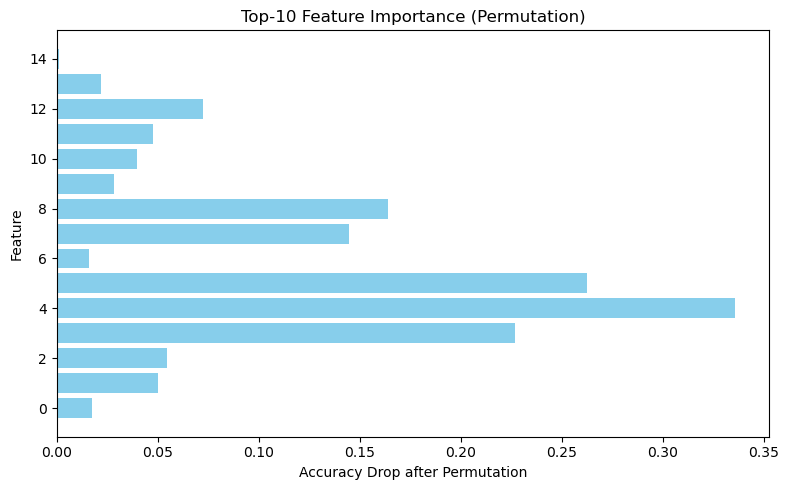

✅ All results saved to SSC_TF_Baseline/


In [31]:
import os, json, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mode
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from scipy.stats import mode

os.makedirs("SSC_TF_Improved", exist_ok=True)
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

num_classes = len(class_names)
F = X_raw.shape[-1]
T = X_raw.shape[1]

print(f"\n=== Training SSC TCN+Attention ===")
print(f"Input shape: {X_raw.shape}, Classes: {class_names}")

# ======================================================
# 🔹 模型定义：Causal TCN + Attention
# ======================================================
import tensorflow as tf
from tensorflow.keras import layers, models

def build_ssc_tcn_attention(input_shape, num_classes, smoothing=0.05):
    inputs = layers.Input(shape=input_shape)

    # 1️⃣ Causal Temporal Block 1
    x = layers.Conv1D(32, 3, padding='causal', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(32, 3, padding='causal', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    res = layers.Conv1D(32, 1, padding='same')(inputs)
    x = layers.Add()([x, res])
    x = layers.ReLU()(x)

    # 2️⃣ Multi-dilated Temporal Block (light)
    res2 = layers.Conv1D(64, 1, padding='same')(x)
    x2 = x
    for d in [1, 2]:
        x2 = layers.Conv1D(64, 3, dilation_rate=d, padding='causal', activation='relu')(x2)
        x2 = layers.BatchNormalization()(x2)
    x = layers.Add()([x2, res2])
    x = layers.ReLU()(x)

    # 🧠 2.5️⃣ Squeeze-and-Excitation Block
    se = layers.GlobalAveragePooling1D()(x)
    se = layers.Dense(x.shape[-1] // 8, activation='relu')(se)
    se = layers.Dense(x.shape[-1], activation='sigmoid')(se)
    se = layers.Multiply()([x, layers.Reshape((1, x.shape[-1]))(se)])

    # 3️⃣ Attention (reduced)
    attn = layers.MultiHeadAttention(num_heads=2, key_dim=16)(se, se)
    x = layers.Add()([se, attn])
    x = layers.LayerNormalization()(x)

    # 4️⃣ Classification Head (compact)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    # === ✅ 修正版 label smoothing loss ===
    def smooth_loss(y_true, y_pred):
        y_true = tf.squeeze(y_true, axis=-1)  # 修正关键：移除 (batch,1)
        y_true = tf.one_hot(tf.cast(y_true, tf.int32), depth=num_classes)
        y_true = y_true * (1 - smoothing) + (smoothing / num_classes)
        return tf.keras.losses.categorical_crossentropy(y_true, y_pred)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss=smooth_loss,
        metrics=['accuracy']
    )

    return model



# ======================================================
# 🔹 GroupKFold 交叉验证
# ======================================================
cv = GroupKFold(n_splits=5)
fold_acc = []
fold_acc_smooth = []
all_y_true, all_y_pred = [], []

def smooth_predictions(y_pred, win=5):
    smoothed = []
    for i in range(len(y_pred)):
        start = max(0, i - win + 1)
        m = mode(y_pred[start:i+1], keepdims=True)
        smoothed.append(m.mode[0])
    return np.array(smoothed)


print("=== Sanity check on input data ===")
print("NaN ratio:", np.isnan(X_raw).mean())
print("Inf ratio:", np.isinf(X_raw).mean())
feat_var = np.var(X_raw.reshape(-1, X_raw.shape[-1]), axis=0)
print("Feature variances:", np.round(feat_var, 6))


for fold, (train_idx, test_idx) in enumerate(cv.split(X_raw, y, groups), start=1):
    print(f"\n=== Fold {fold}/5 ===")

    # —— 基于受试者的训练/测试拆分 —— #
    X_train_raw, y_train, g_train = X_raw[train_idx], y[train_idx], groups[train_idx]
    X_test_raw,  y_test           = X_raw[test_idx],  y[test_idx]

    # —— 训练集内再按受试者切出验证集（10% 受试者） —— #
    gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=SEED + fold)
    tr_sub_idx, val_sub_idx = next(gss.split(X_train_raw, y_train, g_train))
    X_tr_raw, y_tr, g_tr    = X_train_raw[tr_sub_idx], y_train[tr_sub_idx], g_train[tr_sub_idx]
    X_val_raw, y_val        = X_train_raw[val_sub_idx], y_train[val_sub_idx]

    # —— 标准化（仅用训练子集拟合） —— #
    scaler = StandardScaler().fit(X_tr_raw.reshape(-1, F))
    def scale(X): return scaler.transform(X.reshape(-1, F)).reshape(-1, T, F)
    X_tr, X_val, X_test = map(scale, [X_tr_raw, X_val_raw, X_test_raw])

    # —— 类别权重 —— #
    cls_weights = compute_class_weight(class_weight='balanced',
                                       classes=np.arange(num_classes),
                                       y=y_tr)
    class_weight = {i: float(w) for i, w in enumerate(cls_weights)}
    class_weight[1] *= 1.4   # 咳嗽增强
    class_weight[2] *= 1.2   # 过度换气轻增强

    # —— 模型与训练 —— #
    model = build_ssc_tcn_attention((T, F), num_classes)
    cbs = [
        callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)
    ]
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=32,
        verbose=1,
        callbacks=cbs,
        class_weight=class_weight
    )

    # —— 测试 —— #
    y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
    y_pred_smooth = smooth_predictions(y_pred, win=5)

    acc = np.mean(y_pred == y_test)
    acc_smooth = np.mean(y_pred_smooth == y_test)
    print(f"Fold {fold} Accuracy = {acc:.4f}  |  Smoothed = {acc_smooth:.4f}")

    fold_acc.append(acc)
    fold_acc_smooth.append(acc_smooth)
    all_y_true.append(y_test)
    all_y_pred.append(y_pred_smooth)


# ======================================================
# 🔹 汇总结果
# ======================================================
all_y_true = np.concatenate(all_y_true)
all_y_pred = np.concatenate(all_y_pred)
mean_acc, std_acc = np.mean(fold_acc), np.std(fold_acc)
print(f"\n=== Overall Accuracy = {mean_acc:.4f} ± {std_acc:.4f} ===")

report = classification_report(all_y_true, all_y_pred, target_names=class_names, digits=4)
print("\nClassification Report:\n", report)

cm = confusion_matrix(all_y_true, all_y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print("\nConfusion Matrix:\n", cm_df)
# ======================================================
# 🔹 保存结果
# ======================================================

save_dir = "SSC_TF_Baseline"
os.makedirs(save_dir, exist_ok=True)

# 1️⃣ 模型权重
model_path = f"{save_dir}/final_model.keras"
model.save(model_path)

# 打印模型大小
size_kb = os.path.getsize(model_path) / 1024
print(f"💾 Saved model: {model_path} ({size_kb:.2f} KB)")

# 2️⃣ 标准化参数
np.savez(f"{save_dir}/SSC_TF_norm.npz",
         mean=scaler.mean_.astype(np.float32),
         scale=scaler.scale_.astype(np.float32),
         win=np.int32(T),
         feat_dim=np.int32(F))

# 3️⃣ 特征顺序
feat_order = np.arange(F, dtype=np.int32)
np.save(f"{save_dir}/feat_order.npy", feat_order)

# 4️⃣ 类别标签
with open(f"{save_dir}/labels.json", "w", encoding="utf-8") as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

# 5️⃣ 混淆矩阵与报告
cm_df.to_csv(f"{save_dir}/confusion_matrix.csv", index=True)
with open(f"{save_dir}/classification_report.txt", "w") as f:
    f.write(report)

# 6️⃣ 每折准确率
pd.DataFrame({
    "fold": range(1, len(fold_acc) + 1),
    "accuracy": fold_acc
}).to_csv(f"{save_dir}/fold_accuracy.csv", index=False)


# ======================================================
# 🔹 Step: Permutation Feature Importance (基于验证集)
# ======================================================
print("\n=== Permutation Feature Importance (using last fold) ===")

# 使用最后一折的验证集 (或可以改成 X_test)
X_ref, y_ref = X_test.copy(), y_test.copy()
base_acc = np.mean(model.predict(X_ref, verbose=0).argmax(axis=1) == y_ref)
print(f"Baseline accuracy: {base_acc:.4f}")

feat_importance = []

# 对每个特征进行置换打乱
for i in range(F):
    X_perm = X_ref.copy()
    np.random.shuffle(X_perm[:, :, i])  # 打乱该维度特征（保持时间结构）
    acc = np.mean(model.predict(X_perm, verbose=0).argmax(axis=1) == y_ref)
    drop = base_acc - acc
    feat_importance.append((i, drop))

# 排序显示前 20 个最重要特征
feat_importance.sort(key=lambda x: x[1], reverse=True)
top_feats = feat_importance[:20]

print("\nTop Feature Importance (Permutation Drop):")
for i, drop in top_feats:
    print(f"{i:02d} | {feat_order[i]} | ΔAcc = {drop:.4f}")

# 保存为 CSV 文件
imp_df = pd.DataFrame({
    "feature_index": [i for i, _ in feat_importance],
    "feature_name": [feat_order[i] for i, _ in feat_importance],
    "importance_drop": [drop for _, drop in feat_importance]
})
imp_df.to_csv(f"{save_dir}/feature_importance_permutation.csv", index=False)
print(f"📊 Feature importance saved to {save_dir}/feature_importance_permutation.csv")

# 可视化前10个特征重要性
plt.figure(figsize=(8, 5))
plt.barh(
    [feat_order[i] for i, _ in top_feats[::-1]],
    [drop for _, drop in top_feats[::-1]],
    color="skyblue"
)
plt.xlabel("Accuracy Drop after Permutation")
plt.ylabel("Feature")
plt.title("Top-10 Feature Importance (Permutation)")
plt.tight_layout()
plt.savefig(f"{save_dir}/feature_importance_plot.png", dpi=300)
plt.show()


print(f"✅ All results saved to {save_dir}/")



In [32]:
import tensorflow as tf
import numpy as np
import os

# 路径与输出文件夹
SAVE_DIR = "SSC_TF_Baseline"
MODEL_PATH = os.path.join(SAVE_DIR, "final_model.keras")

# === 1️⃣ 加载模型 ===
print("🔹 Loading trained model...")
model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={"smooth_loss": lambda y_true, y_pred: tf.reduce_mean(y_pred)}  # 兼容自定义loss
)
print("✅ Model loaded successfully.")

# === 2️⃣ 创建基础转换器 ===
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# =========================================================
# 选项 A: 动态范围量化 (Dynamic Range Quantization)
# =========================================================
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model_dynamic = converter.convert()
dynamic_path = os.path.join(SAVE_DIR, "final_model_quantized.tflite")

with open(dynamic_path, "wb") as f:
    f.write(tflite_model_dynamic)
print(f"💾 Saved dynamic-range quantized model to: {dynamic_path}")

# =========================================================
# 选项 B: Float16 量化 (适合 GPU/TPU / 移动端兼容)
# =========================================================
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_model_fp16 = converter.convert()
fp16_path = os.path.join(SAVE_DIR, "final_model_quantized_fp16.tflite")

with open(fp16_path, "wb") as f:
    f.write(tflite_model_fp16)
print(f"💾 Saved float16 quantized model to: {fp16_path}")

# =========================================================
# 选项 C: （可选）Int8 量化（需要校准样本）
# =========================================================
# 若你以后想使用 int8 量化，请保留此模板
# def representative_dataset():
#     for _ in range(100):
#         # 随机抽取一小批样本（假设 X_raw 是原始输入）
#         data = X_raw[np.random.randint(0, len(X_raw), size=1)]
#         yield [data.astype(np.float32)]

# converter = tf.lite.TFLiteConverter.from_keras_model(model)
# converter.optimizations = [tf.lite.Optimize.DEFAULT]
# converter.representative_dataset = representative_dataset
# converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
# converter.inference_input_type = tf.int8
# converter.inference_output_type = tf.int8
# tflite_model_int8 = converter.convert()
# int8_path = os.path.join(SAVE_DIR, "final_model_quantized_int8.tflite")
# with open(int8_path, "wb") as f:
#     f.write(tflite_model_int8)
# print(f"💾 Saved int8 quantized model to: {int8_path}")

# =========================================================
# ✅ 打印模型大小
# =========================================================
size_base = os.path.getsize(MODEL_PATH) / 1024
size_dynamic = os.path.getsize(dynamic_path) / 1024
size_fp16 = os.path.getsize(fp16_path) / 1024

print("\n📊 Model size comparison:")
print(f" - Original Keras model:     {size_base:.2f} KB")
print(f" - Dynamic-range TFLite:     {size_dynamic:.2f} KB")
print(f" - Float16 TFLite:           {size_fp16:.2f} KB")

print("\n✅ Quantization complete. Files saved to:", SAVE_DIR)


🔹 Loading trained model...
✅ Model loaded successfully.
INFO:tensorflow:Assets written to: C:\Users\ROG666\AppData\Local\Temp\tmpfyq724xh\assets


INFO:tensorflow:Assets written to: C:\Users\ROG666\AppData\Local\Temp\tmpfyq724xh\assets


💾 Saved dynamic-range quantized model to: SSC_TF_Baseline\final_model_quantized.tflite
INFO:tensorflow:Assets written to: C:\Users\ROG666\AppData\Local\Temp\tmp0g7lg66r\assets


INFO:tensorflow:Assets written to: C:\Users\ROG666\AppData\Local\Temp\tmp0g7lg66r\assets


💾 Saved float16 quantized model to: SSC_TF_Baseline\final_model_quantized_fp16.tflite

📊 Model size comparison:
 - Original Keras model:     602.39 KB
 - Dynamic-range TFLite:     79.02 KB
 - Float16 TFLite:           112.17 KB

✅ Quantization complete. Files saved to: SSC_TF_Baseline


In [35]:
import os
import pandas as pd

DATA_DIR = "../social_signal_2526"  # 按你的路径调整
target_cols = ['accelx', 'accely', 'accelz']  # 小写对比

def check_accel_columns(file_path):
    try:
        df = pd.read_csv(file_path, nrows=5)  # 只读前几行，速度快
        cols = [c.lower() for c in df.columns]
        has_all = all(c in cols for c in target_cols)
        return has_all, df.columns.tolist()
    except Exception as e:
        return False, str(e)

missing_files = []

for activity in sorted(os.listdir(DATA_DIR)):
    act_dir = os.path.join(DATA_DIR, activity)
    if not os.path.isdir(act_dir):
        continue

    for file in sorted(os.listdir(act_dir)):
        if not file.lower().endswith(".csv"):
            continue
        path = os.path.join(act_dir, file)
        ok, cols = check_accel_columns(path)
        if not ok:
            missing_files.append((activity, file, cols))

print("\n=== 检查结果 ===")
if not missing_files:
    print("✅ 所有文件都包含 accelX/accelY/accelZ 列！")
else:
    for act, file, cols in missing_files:
        print(f"⚠️ {act}/{file} 缺少目标列，实际列名: {cols}")



=== 检查结果 ===
⚠️ breathing/breathingNormal (178).csv 缺少目标列，实际列名: ['1759956346585', '1057826231', '24580', '0', '0.191162109375', '-0.99810791015625', '-0.00640869140625']
⚠️ breathing/breathingNormal (77).csv 缺少目标列，实际列名: ['1760387165167', '1482691269', '12796', '0', '-0.154541015625', '-1.02423095703125', '-0.09356689453125']


In [37]:

"""
===========================================================
SSC Quantized TFLite Model LOSO Evaluation (Full Feature Ver.)
Author: Taian Peng
Date: 2025-11-10
===========================================================
"""

import os
import json
import numpy as np
import pandas as pd
from scipy.signal import welch
from tensorflow.lite.python.interpreter import Interpreter
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tabulate import tabulate

# ============================================================
# 1️⃣ 基础配置
# ============================================================
DATA_DIR = "../social_signal_2526"
MODEL_PATH = "SSC_TF_Baseline/final_model_quantized_fp16.tflite"
NORM_PATH = "SSC_TF_Baseline/SSC_TF_norm.npz"
LABELS_PATH = "SSC_TF_Baseline/labels.json"

FS = 12.5
WIN = 50
STEP = 10
EPS = 1e-8

FEAT_CANDIDATES = [
    'accelX','accelY','accelZ',
    'linAccMag','jerkMag','jerk_rms',
    'burst_density','breathing_stability','rhythm_stability','cough_energy_ratio',
    'dominant_resp_freq','spectral_sharpness','zero_cross_rate','short_energy_ratio','breathing_disruption'
]

FOLDER_TO_LABEL = {
    "breathing": "breathingNormally",
    "coughing": "coughing",
    "hyperventilate": "hyperventilation",
    "other": "other"
}

# ============================================================
# 2️⃣ 加载模型与归一化参数
# ============================================================
norm = np.load(NORM_PATH)
mean, scale = norm["mean"], norm["scale"]
win, feat_dim = int(norm["win"]), int(norm["feat_dim"])

with open(LABELS_PATH, "r", encoding="utf-8") as f:
    class_names = json.load(f)

print(f"✅ Loaded normalization params: win={win}, feat_dim={feat_dim}")
print(f"✅ Loaded {len(class_names)} classes: {class_names}")

interpreter = Interpreter(model_path=MODEL_PATH, num_threads=4)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# ============================================================
# 3️⃣ 滑动窗口
# ============================================================
def make_windows(X, win=50, step=10):
    if len(X) < win:
        return np.empty((0, win, X.shape[1]))
    idxs = range(0, len(X) - win + 1, step)
    return np.stack([X[i:i + win] for i in idxs])

# ============================================================
# 4️⃣ 特征计算（完整 15维版本）
# ============================================================
def compute_features(df, alpha=0.98, eps=1e-8, win=20, fs=12.5):
    df = df.fillna(0)
    cols_lower = {c.lower(): c for c in df.columns}
    possible_sets = [['accelx','accely','accelz'], ['accx','accy','accz'], ['x','y','z']]
    found = None
    for cand in possible_sets:
        if all(c in cols_lower for c in cand):
            found = [cols_lower[c] for c in cand]
            break
    if not found:
        print(f"⚠️ Missing accel columns: {list(df.columns)}")
        return pd.DataFrame(columns=FEAT_CANDIDATES)

    a = df[found].to_numpy(float)
    n = len(a)
    if n < 3:
        return pd.DataFrame(columns=FEAT_CANDIDATES)

    # --- 重力滤波 ---
    g = np.zeros_like(a)
    g[0] = a[0]
    for i in range(1, n):
        g[i] = alpha * g[i-1] + (1 - alpha) * a[i]
    lin = a - g
    jerk = np.vstack([np.zeros(3), np.diff(a, axis=0)])

    accelMag = np.linalg.norm(a, axis=1)
    linAccMag = np.linalg.norm(lin, axis=1)
    jerkMag = np.linalg.norm(jerk, axis=1)
    a_vert = a[:, 2]

    jerk_rms = pd.Series(jerkMag).rolling(win, min_periods=1).apply(lambda x: np.sqrt(np.mean(x**2)), raw=True).fillna(0).to_numpy()
    breathing_stability = 1 - pd.Series(a_vert).rolling(win, min_periods=1).std().fillna(1.0).to_numpy()
    breathing_stability = np.clip(breathing_stability, 0, 1)
    diffs = np.abs(pd.Series(a_vert).diff().fillna(0))
    rhythm_stability = 1 - diffs.rolling(win, min_periods=1).mean().fillna(1.0).to_numpy()
    rhythm_stability = np.clip(rhythm_stability, 0, 1)

    jerk_series = pd.Series(jerkMag)
    local_mean = jerk_series.rolling(win*2, min_periods=10).mean().fillna(eps)
    local_std = jerk_series.rolling(win*2, min_periods=10).std().fillna(eps)
    thr = local_mean + 2.5 * local_std
    peaks = (jerk_series > thr).astype(float)
    burst_density = peaks.rolling(win, min_periods=1).mean().fillna(0).to_numpy()

    short_win, long_win = 5, 50
    short_energy = jerk_series.rolling(short_win, min_periods=1).mean().fillna(eps)
    long_energy = jerk_series.rolling(long_win, min_periods=10).mean().fillna(eps)
    cough_energy_ratio = np.clip(short_energy / long_energy, 0, 10).to_numpy()

    def dominant_freq_fast(sig):
        sig = pd.Series(sig).ffill().bfill().to_numpy()
        n = len(sig)
        dom = np.zeros(n)
        if n < 64: return dom
        for i in range(0, n, 10):
            seg = sig[max(0, i-64):i]
            if len(seg) < 16 or np.std(seg) < eps: continue
            f = np.fft.rfftfreq(len(seg), 1/fs)
            Pxx = np.abs(np.fft.rfft(seg))**2
            mask = (f >= 0.1) & (f <= 2.0)
            if np.any(mask):
                dom[i] = f[mask][np.argmax(Pxx[mask])]
        return pd.Series(dom).replace(0, np.nan).ffill().fillna(0).clip(0,2).to_numpy()

    dominant_resp_freq = dominant_freq_fast(a_vert)

    def safe_spectral_sharpness(x):
        if len(x) < 16 or np.std(x) < eps: return 0.0
        f, Pxx = welch(x, fs=fs, nperseg=min(64, len(x)), noverlap=0)
        Pxx = Pxx / (np.sum(Pxx) + eps)
        return np.max(Pxx)

    spectral_sharpness = pd.Series(accelMag).rolling(64, min_periods=10).apply(safe_spectral_sharpness, raw=True).fillna(0).to_numpy()
    zero_cross_rate = ((np.sign(pd.Series(a_vert)) != np.sign(pd.Series(a_vert).shift(1))).astype(float)
                       .rolling(64, min_periods=2).mean().fillna(0).to_numpy())

    short_energy_ratio = np.clip(
        pd.Series(linAccMag).rolling(8, min_periods=2).mean().fillna(eps) /
        pd.Series(linAccMag).rolling(32, min_periods=5).mean().fillna(eps),
        0, 10).to_numpy()

    b_stab = pd.Series(breathing_stability)
    breathing_disruption = (b_stab.diff().fillna(0) < -0.05).rolling(10, min_periods=1).sum()
    breathing_disruption = np.clip(breathing_disruption / 10.0, 0, 1).to_numpy()

    feat_df = pd.DataFrame({
        'accelX': a[:, 0],
        'accelY': a[:, 1],
        'accelZ': a[:, 2],
        'linAccMag': linAccMag,
        'jerkMag': jerkMag,
        'jerk_rms': jerk_rms,
        'burst_density': burst_density,
        'breathing_stability': breathing_stability,
        'rhythm_stability': rhythm_stability,
        'cough_energy_ratio': cough_energy_ratio,
        'dominant_resp_freq': dominant_resp_freq,
        'spectral_sharpness': spectral_sharpness,
        'zero_cross_rate': zero_cross_rate,
        'short_energy_ratio': short_energy_ratio,
        'breathing_disruption': breathing_disruption
    })
    return feat_df.fillna(0)

# ============================================================
# 5️⃣ 模型推理函数
# ============================================================
def predict_windows(X_scaled):
    preds = []
    for i in range(len(X_scaled)):
        interpreter.set_tensor(input_details[0]['index'], X_scaled[i:i+1].astype(np.float32))
        interpreter.invoke()
        out = interpreter.get_tensor(output_details[0]['index'])
        preds.append(np.argmax(out))
    return np.array(preds)

# ============================================================
# 6️⃣ 每个 CSV 文件单独推理（非交叉验证）
# ============================================================
subject_results = []
all_y_true, all_y_pred = [], []

for activity in sorted(os.listdir(DATA_DIR)):
    act_dir = os.path.join(DATA_DIR, activity)
    if not os.path.isdir(act_dir):
        continue

    label_name = FOLDER_TO_LABEL.get(activity, activity)
    if label_name not in class_names:
        continue
    label_id = class_names.index(label_name)

    print(f"\n=== Evaluating activity folder: {activity} ({label_name}) ===")

    files = sorted([f for f in os.listdir(act_dir) if f.lower().endswith(".csv")])
    for file in files:
        path = os.path.join(act_dir, file)
        try:
            df = pd.read_csv(path)
        except Exception as e:
            print(f"⚠️ Failed to read {file}: {e}")
            continue
        if len(df) < WIN:
            continue

        # 计算特征
        feat_df = compute_features(df)
        if feat_df.empty:
            continue

        # 特征缩放 + 滑动窗口
        X = feat_df[FEAT_CANDIDATES].to_numpy()
        X_scaled = (X - mean[:X.shape[1]]) / (scale[:X.shape[1]] + 1e-8)
        X_win = make_windows(X_scaled, WIN, STEP)
        if len(X_win) == 0:
            continue

        # 模型推理
        preds = predict_windows(X_win)

        # 文件级准确率
        acc = np.mean(preds == label_id)
        subject_results.append((file, label_name, acc))

        # ✅ 修复拼写错误：改成 all_y_true / all_y_pred
        all_y_true.extend([label_id] * len(preds))
        all_y_pred.extend(preds)

        print(f"✅ {activity}/{file}: acc={acc:.4f} ({len(preds)} windows)")

# ============================================================
# 7️⃣ 汇总结果
# ============================================================
print("\n=== Overall Results ===")
report = classification_report(all_y_true, y_pred_all, target_names=class_names, digits=4)
cm = confusion_matrix(all_y_true, y_pred_all)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

print(tabulate(cm_df, headers='keys', tablefmt='github', showindex=True))
print(report)

# 保存结果
os.makedirs("SSC_TF_Evaluation_PredictOnly", exist_ok=True)
cm_df.to_csv("SSC_TF_Evaluation_PredictOnly/confusion_matrix.csv", index=True)
with open("SSC_TF_Evaluation_PredictOnly/classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)
pd.DataFrame(subject_results, columns=["subject_file", "class", "accuracy"]).to_csv(
    "SSC_TF_Evaluation_PredictOnly/subject_acc.csv", index=False
)
print("\n✅ All prediction results saved to SSC_TF_Evaluation_PredictOnly/")

# ============================================================
# 7️⃣ 汇总结果
# ============================================================
print("\n=== Overall Results ===")
report = classification_report(all_y_true, all_y_pred, target_names=class_names, digits=4)
cm = confusion_matrix(all_y_true, all_y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print(tabulate(cm_df, headers='keys', tablefmt='github', showindex=True))
print(report)

os.makedirs("SSC_TF_Evaluation_LOSO", exist_ok=True)
cm_df.to_csv("SSC_TF_Evaluation_LOSO/confusion_matrix.csv", index=True)
with open("SSC_TF_Evaluation_LOSO/classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)
pd.DataFrame(subject_results, columns=["subject_file", "class", "accuracy"]).to_csv("SSC_TF_Evaluation_LOSO/subject_fold_acc.csv", index=False)
print("\n✅ All LOSO results saved to SSC_TF_Evaluation_LOSO/")


✅ Loaded normalization params: win=50, feat_dim=15
✅ Loaded 4 classes: ['breathingNormally', 'coughing', 'hyperventilation', 'other']

=== Evaluating activity folder: breathing (breathingNormally) ===
✅ breathing/breathingNormal (1).csv: acc=1.0000 (33 windows)
✅ breathing/breathingNormal (10).csv: acc=1.0000 (32 windows)
✅ breathing/breathingNormal (100).csv: acc=1.0000 (35 windows)
✅ breathing/breathingNormal (101).csv: acc=1.0000 (35 windows)
✅ breathing/breathingNormal (102).csv: acc=1.0000 (31 windows)
✅ breathing/breathingNormal (103).csv: acc=1.0000 (31 windows)
✅ breathing/breathingNormal (104).csv: acc=0.9688 (32 windows)
✅ breathing/breathingNormal (105).csv: acc=1.0000 (32 windows)
✅ breathing/breathingNormal (106).csv: acc=1.0000 (32 windows)
✅ breathing/breathingNormal (107).csv: acc=1.0000 (35 windows)
✅ breathing/breathingNormal (108).csv: acc=1.0000 (36 windows)
✅ breathing/breathingNormal (109).csv: acc=0.8235 (34 windows)
✅ breathing/breathingNormal (11).csv: acc=1.00

ValueError: Found input variables with inconsistent numbers of samples: [63235, 66118]

Using device: cuda
使用全部 2408 位受试者进行 GroupKFold 交叉验证。

=== Fold 1/5 ===


c:\Users\ROG666\anaconda3\envs\har310\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 01 | Train Loss=0.3418, Acc=0.7696 | Val Loss=0.2771, Acc=0.8313
Epoch 02 | Train Loss=0.2809, Acc=0.8334 | Val Loss=0.2721, Acc=0.8238
Epoch 03 | Train Loss=0.2660, Acc=0.8484 | Val Loss=0.2667, Acc=0.8504
Epoch 04 | Train Loss=0.2579, Acc=0.8579 | Val Loss=0.2626, Acc=0.8509
Epoch 05 | Train Loss=0.2477, Acc=0.8681 | Val Loss=0.2605, Acc=0.8543
Epoch 06 | Train Loss=0.2408, Acc=0.8771 | Val Loss=0.2627, Acc=0.8368
Epoch 07 | Train Loss=0.2370, Acc=0.8813 | Val Loss=0.2531, Acc=0.8687
Epoch 08 | Train Loss=0.2323, Acc=0.8874 | Val Loss=0.2560, Acc=0.8647
Epoch 09 | Train Loss=0.2274, Acc=0.8938 | Val Loss=0.2566, Acc=0.8620
Epoch 10 | Train Loss=0.2247, Acc=0.8972 | Val Loss=0.2489, Acc=0.8744
Epoch 11 | Train Loss=0.2218, Acc=0.9001 | Val Loss=0.2536, Acc=0.8720
Epoch 12 | Train Loss=0.2193, Acc=0.9037 | Val Loss=0.2624, Acc=0.8616
Epoch 13 | Train Loss=0.2161, Acc=0.9082 | Val Loss=0.2600, Acc=0.8705
Epoch 14 | Train Loss=0.2131, Acc=0.9116 | Val Loss=0.2789, Acc=0.8465
Epoch 

c:\Users\ROG666\anaconda3\envs\har310\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 01 | Train Loss=0.3411, Acc=0.7737 | Val Loss=0.2636, Acc=0.8545
Epoch 02 | Train Loss=0.2828, Acc=0.8349 | Val Loss=0.2742, Acc=0.8119
Epoch 03 | Train Loss=0.2673, Acc=0.8510 | Val Loss=0.2476, Acc=0.8602
Epoch 04 | Train Loss=0.2549, Acc=0.8647 | Val Loss=0.2495, Acc=0.8430
Epoch 05 | Train Loss=0.2472, Acc=0.8732 | Val Loss=0.2609, Acc=0.8351
Epoch 06 | Train Loss=0.2427, Acc=0.8781 | Val Loss=0.2363, Acc=0.8704
Epoch 07 | Train Loss=0.2363, Acc=0.8856 | Val Loss=0.2466, Acc=0.8565
Epoch 08 | Train Loss=0.2322, Acc=0.8907 | Val Loss=0.2533, Acc=0.8687
Epoch 09 | Train Loss=0.2303, Acc=0.8921 | Val Loss=0.2453, Acc=0.8720
Epoch 10 | Train Loss=0.2251, Acc=0.8987 | Val Loss=0.2401, Acc=0.8681
Epoch 11 | Train Loss=0.2217, Acc=0.9008 | Val Loss=0.2498, Acc=0.8605
Epoch 12 | Train Loss=0.2206, Acc=0.9033 | Val Loss=0.2435, Acc=0.8808
Epoch 13 | Train Loss=0.2112, Acc=0.9157 | Val Loss=0.2443, Acc=0.8746
Epoch 14 | Train Loss=0.2101, Acc=0.9167 | Val Loss=0.2419, Acc=0.8776
Epoch 

...

Epoch 01 | Train Loss=0.3397, Acc=0.7720 | Val Loss=0.2597, Acc=0.8463
Epoch 02 | Train Loss=0.2844, Acc=0.8258 | Val Loss=0.2501, Acc=0.8624
Epoch 03 | Train Loss=0.2684, Acc=0.8434 | Val Loss=0.2528, Acc=0.8547
Epoch 04 | Train Loss=0.2566, Acc=0.8572 | Val Loss=0.2554, Acc=0.8581
Epoch 05 | Train Loss=0.2484, Acc=0.8670 | Val Loss=0.2337, Acc=0.8778
Epoch 06 | Train Loss=0.2402, Acc=0.8759 | Val Loss=0.2528, Acc=0.8580
Epoch 07 | Train Loss=0.2373, Acc=0.8790 | Val Loss=0.2501, Acc=0.8529
Epoch 08 | Train Loss=0.2323, Acc=0.8855 | Val Loss=0.2302, Acc=0.8782
Epoch 09 | Train Loss=0.2279, Acc=0.8933 | Val Loss=0.2497, Acc=0.8789
Epoch 10 | Train Loss=0.2249, Acc=0.8947 | Val Loss=0.2501, Acc=0.8670
Epoch 11 | Train Loss=0.2209, Acc=0.8988 | Val Loss=0.2519, Acc=0.8761
Epoch 12 | Train Loss=0.2174, Acc=0.9042 | Val Loss=0.2474, Acc=0.8807
Epoch 13 | Train Loss=0.2156, Acc=0.9079 | Val Loss=0.2460, Acc=0.8775
Epoch 14 | Train Loss=0.2135, Acc=0.9105 | Val Loss=0.2390, Acc=0.8855
Epoch 

c:\Users\ROG666\anaconda3\envs\har310\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 01 | Train Loss=0.3408, Acc=0.7705 | Val Loss=0.2871, Acc=0.8086
Epoch 02 | Train Loss=0.2842, Acc=0.8311 | Val Loss=0.2617, Acc=0.8481
Epoch 03 | Train Loss=0.2717, Acc=0.8442 | Val Loss=0.2546, Acc=0.8525
Epoch 04 | Train Loss=0.2606, Acc=0.8563 | Val Loss=0.2673, Acc=0.8356
Epoch 05 | Train Loss=0.2528, Acc=0.8650 | Val Loss=0.2528, Acc=0.8486
Epoch 06 | Train Loss=0.2467, Acc=0.8716 | Val Loss=0.2553, Acc=0.8416
Epoch 07 | Train Loss=0.2406, Acc=0.8800 | Val Loss=0.2619, Acc=0.8468
Epoch 08 | Train Loss=0.2371, Acc=0.8835 | Val Loss=0.2435, Acc=0.8725
Epoch 09 | Train Loss=0.2318, Acc=0.8908 | Val Loss=0.2398, Acc=0.8750
Epoch 10 | Train Loss=0.2276, Acc=0.8948 | Val Loss=0.2481, Acc=0.8580
Epoch 11 | Train Loss=0.2247, Acc=0.8987 | Val Loss=0.2510, Acc=0.8672
Epoch 12 | Train Loss=0.2228, Acc=0.9014 | Val Loss=0.2438, Acc=0.8671
Epoch 13 | Train Loss=0.2179, Acc=0.9065 | Val Loss=0.2523, Acc=0.8648
Epoch 14 | Train Loss=0.2160, Acc=0.9095 | Val Loss=0.2511, Acc=0.8734
Epoch 

c:\Users\ROG666\anaconda3\envs\har310\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


Epoch 01 | Train Loss=0.3479, Acc=0.7600 | Val Loss=0.2795, Acc=0.8143
Epoch 02 | Train Loss=0.2866, Acc=0.8277 | Val Loss=0.2632, Acc=0.8452
Epoch 03 | Train Loss=0.2705, Acc=0.8447 | Val Loss=0.2668, Acc=0.8369
Epoch 04 | Train Loss=0.2606, Acc=0.8571 | Val Loss=0.2573, Acc=0.8494
Epoch 05 | Train Loss=0.2519, Acc=0.8687 | Val Loss=0.2519, Acc=0.8481
Epoch 06 | Train Loss=0.2456, Acc=0.8747 | Val Loss=0.2657, Acc=0.8321
Epoch 07 | Train Loss=0.2399, Acc=0.8816 | Val Loss=0.2459, Acc=0.8679
Epoch 08 | Train Loss=0.2362, Acc=0.8852 | Val Loss=0.2516, Acc=0.8556
Epoch 09 | Train Loss=0.2310, Acc=0.8927 | Val Loss=0.2604, Acc=0.8400
Epoch 10 | Train Loss=0.2279, Acc=0.8957 | Val Loss=0.2552, Acc=0.8612
Epoch 11 | Train Loss=0.2255, Acc=0.8989 | Val Loss=0.2452, Acc=0.8739
Epoch 12 | Train Loss=0.2227, Acc=0.9012 | Val Loss=0.2420, Acc=0.8645
Epoch 13 | Train Loss=0.2208, Acc=0.9043 | Val Loss=0.2527, Acc=0.8657
Epoch 14 | Train Loss=0.2180, Acc=0.9070 | Val Loss=0.2475, Acc=0.8701
Epoch 

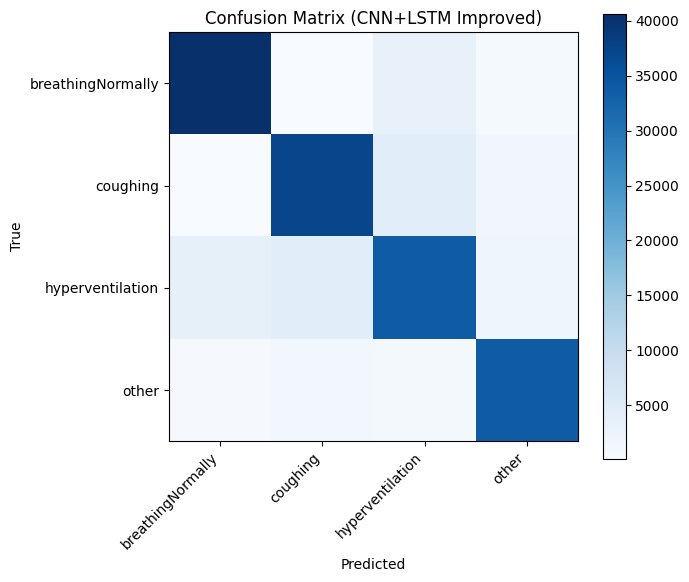

In [13]:
import os, json, random, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset, WeightedRandomSampler

# ======================================================
# 固定随机种子
# ======================================================
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ======================================================
# 类别名称
# ======================================================
class_names = ['breathingNormally', 'coughing', 'hyperventilation', 'other']
num_classes = len(class_names)

# ======================================================
# 目录创建
# ======================================================
os.makedirs("results", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("SSC_CNN_models", exist_ok=True)

# ======================================================
# 🔹 SEBlock 模块（轻量注意力）
# ======================================================
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.fc1 = nn.Linear(channels, channels // reduction)
        self.fc2 = nn.Linear(channels // reduction, channels)
    def forward(self, x):
        w = x.mean(-1)
        w = torch.relu(self.fc1(w))
        w = torch.sigmoid(self.fc2(w)).unsqueeze(-1)
        return x * w

# ======================================================
# 🔹 CNN + LSTM 模型定义（增强版）
# ======================================================
class RegularizedCNNLSTM(nn.Module):
    def __init__(self, input_dim, num_classes, l2_reg=1e-4):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, 64, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(64)
        self.dropout1 = nn.Dropout(0.2)

        self.conv2 = nn.Conv1d(64, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)

        self.se = SEBlock(64)  # ✅ 注意力增强

        self.lstm = nn.LSTM(64, 64, batch_first=True, dropout=0.3)
        self.fc1 = nn.Linear(64, 64)
        self.dropout2 = nn.Dropout(0.4)
        self.fc_out = nn.Linear(64, num_classes)
        self.l2_reg = l2_reg

    def forward(self, x):
        x = x.permute(0, 2, 1)  # Conv1d expects (B, F, T)
        x = torch.relu(self.bn1(self.conv1(x)))
        x = self.dropout1(x)

        res = x
        x = torch.relu(self.bn2(self.conv2(x)))
        x = x + res
        x = self.se(x)  # ✅ SE 注意力

        x = x.permute(0, 2, 1)  # LSTM expects (B, T, F)
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        x = torch.relu(self.fc1(x))
        x = self.dropout2(x)
        out = self.fc_out(x)
        return out

# ======================================================
# 🔹 Smooth Focal Loss（类别权重 + 平滑）
# ======================================================
class SmoothFocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, smoothing=0.05, num_classes=4):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = smoothing
        self.num_classes = num_classes

    def forward(self, logits, targets):
        with torch.no_grad():
            true_dist = torch.zeros_like(logits)
            true_dist.fill_(self.smoothing / (self.num_classes - 1))
            true_dist.scatter_(1, targets.unsqueeze(1), 1 - self.smoothing)

        log_probs = torch.nn.functional.log_softmax(logits, dim=1)
        probs = log_probs.exp()
        focal = ((1 - probs) ** self.gamma) * log_probs
        loss = -torch.sum(true_dist * focal, dim=1)
        if self.alpha is not None:
            loss = loss * self.alpha[targets]
        return loss.mean()

# ======================================================
# 工具函数
# ======================================================
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()

        # === 前向传播 ===
        out = model(Xb)
        loss = criterion(out, yb)

        # === temporal smoothing loss（仅对 hyperventilation 样本轻微施加） ===
        if yb.eq(2).any():  # 类别索引2 = hyperventilation
            probs = torch.softmax(out, dim=1)
            p2 = probs[:, 2]
            if len(p2) > 1:
                smooth_loss = ((p2[1:] - p2[:-1]) ** 2).mean()
                loss = loss + 0.1 * smooth_loss  # λ=0.1 可调

        # === 反向传播 ===
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(Xb)
        correct += (out.argmax(1) == yb).sum().item()
        total += len(Xb)

    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion, adjust_hypervent=True, threshold=0.45):
    """
    后处理：若预测为 hyperventilation (索引2)，且置信度低于 threshold，
    则改为次高概率的类别，以减少误判。
    """
    model.eval()
    total_loss, correct, total = 0, 0, 0
    preds, trues = [], []

    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        out = model(Xb)
        probs = torch.softmax(out, dim=1)
        loss = criterion(out, yb)

        total_loss += loss.item() * len(Xb)
        total += len(Xb)

        pred = probs.argmax(1)

        if adjust_hypervent:
            mask = pred == 2
            if mask.any():
                conf = probs[mask, 2]
                top2 = torch.topk(probs[mask], 2, dim=1).indices[:, 1]
                # ✅ 新增：滑动平均置信度平滑，防止呼吸被误判为咳嗽
                conf_smooth = torch.nn.functional.avg_pool1d(conf.unsqueeze(0).unsqueeze(0), kernel_size=3, stride=1, padding=1).squeeze()
                pred[mask] = torch.where(conf_smooth < threshold, top2, pred[mask])


        correct += (pred == yb).sum().item()
        preds.append(pred.cpu())
        trues.append(yb.cpu())

    preds = torch.cat(preds).numpy()
    trues = torch.cat(trues).numpy()
    return total_loss / total, correct / total, preds, trues


# ======================================================
# 主训练循环
# ======================================================
X_all_train, y_all_train, groups_train = X_raw, y, groups
print(f"使用全部 {len(np.unique(groups_train))} 位受试者进行 GroupKFold 交叉验证。")

cv = GroupKFold(n_splits=5)
fold_acc = []
all_y_true, all_y_pred = [], []

for fold, (train_idx, test_idx) in enumerate(cv.split(X_all_train, y_all_train, groups_train), start=1):
    print(f"\n=== Fold {fold}/5 ===")
    X_train_raw, y_train = X_all_train[train_idx], y_all_train[train_idx]
    X_test_raw,  y_test  = X_all_train[test_idx],  y_all_train[test_idx]
    groups_train_sub = groups_train[train_idx]

    # --- 划分验证集 ---
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=SEED)
    tr_idx, val_idx = next(splitter.split(X_train_raw, y_train, groups_train_sub))
    X_tr_raw, y_tr = X_train_raw[tr_idx], y_train[tr_idx]
    X_val_raw, y_val = X_train_raw[val_idx], y_train[val_idx]

    # --- 标准化 ---
    F = X_tr_raw.shape[-1]
    scaler = StandardScaler().fit(X_tr_raw.reshape(-1, F))
    def scale(X): return scaler.transform(X.reshape(-1, F)).reshape(-1, X.shape[1], F)
    X_tr, X_val, X_test = map(scale, [X_tr_raw, X_val_raw, X_test_raw])

    # --- Tensor 转换 ---
    X_tr, y_tr = torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.long)
    X_val, y_val = torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long)
    X_test, y_test = torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long)

    # === WeightedRandomSampler ===
    class_sample_count = np.array([len(np.where(y_tr.numpy() == t)[0]) for t in np.unique(y_tr.numpy())])
    weights = 1. / class_sample_count
    samples_weight = np.array([weights[t] for t in y_tr.numpy()])
    sampler = WeightedRandomSampler(weights=samples_weight, num_samples=len(samples_weight), replacement=True)
    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, sampler=sampler)
    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=64)
    test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64)

    # === 类别权重 ===
    cls_weights_np = compute_class_weight('balanced', classes=np.arange(num_classes), y=y_tr.numpy())
    cls_weights = torch.tensor(cls_weights_np, dtype=torch.float32, device=device)

    # 给予 hyperventilation 类别更大的权重，假设其类别索引为2
    # ✅ 动态调权：增强 hyperventilation，但不过度放大
    cls_weights[2] = cls_weights[2] * 1.8
    cls_weights = cls_weights / cls_weights.mean()  # 归一化，防止权重失衡


    # --- 构建模型与损失 ---
    model = RegularizedCNNLSTM(F, num_classes).to(device)
    optimizer = optim.Adam(model.parameters(), lr=3e-4)
    criterion = SmoothFocalLoss(alpha=cls_weights, gamma=2.0, smoothing=0.05, num_classes=num_classes)

    best_val_loss = float('inf')
    patience, wait = 10, 0
    lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    # === 训练阶段 ===
    for epoch in range(1, 41):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, _, _ = eval_epoch(model, val_loader, criterion)
        lr_scheduler.step(val_loss)
        print(f"Epoch {epoch:02d} | Train Loss={tr_loss:.4f}, Acc={tr_acc:.4f} | Val Loss={val_loss:.4f}, Acc={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "models/best_tmp.pt")
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping!")
                break

    # --- 加载最佳模型 ---
    model.load_state_dict(torch.load("models/best_tmp.pt"))
    _, acc, y_pred, y_true = eval_epoch(model, test_loader, criterion)
    print(f"Fold {fold} accuracy = {acc:.4f}")
    fold_acc.append(acc)
    all_y_true.append(y_true)
    all_y_pred.append(y_pred)


# ======================================================
# 结果统计与保存
# ======================================================
all_y_true = np.concatenate(all_y_true)
all_y_pred = np.concatenate(all_y_pred)
mean_acc, std_acc = np.mean(fold_acc), np.std(fold_acc)
print(f"\n=== Overall Accuracy = {mean_acc:.4f} ± {std_acc:.4f}")

report = classification_report(all_y_true, all_y_pred, target_names=class_names, digits=4)
print("\nClassification Report:\n", report)

cm = confusion_matrix(all_y_true, all_y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print("\nConfusion Matrix:\n", cm_df)

# 保存结果
torch.save(model.state_dict(), "SSC_CNN_models/final_model.pt")
model_path = "SSC_CNN_models/final_model.pt"
size_kb = os.path.getsize(model_path) / 1024
print(f" Saved model: {model_path} ({size_kb:.2f} KB)")
np.savez("SSC_CNN_models/SSC_CNN_LSTM_norm.npz",
         mean=scaler.mean_.astype(np.float32),
         scale=scaler.scale_.astype(np.float32),
         win=np.int32(X_tr.shape[1]),
         feat_dim=np.int32(X_tr.shape[2]))
np.save("SSC_CNN_models/feat_order.npy", np.arange(X_tr.shape[-1]))
with open("SSC_CNN_models/SSC_CNN_LSTM_labels.json", "w", encoding="utf-8") as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

cm_df.to_csv("results/confusion_matrix.csv")
with open("results/classification_report.txt", "w") as f:
    f.write(report)
pd.DataFrame({"fold": range(1, 6), "accuracy": fold_acc}).to_csv("results/fold_accuracy.csv", index=False)

# 混淆矩阵可视化
plt.figure(figsize=(7,6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix (CNN+LSTM Improved)")
plt.colorbar()
plt.xticks(np.arange(num_classes), class_names, rotation=45, ha='right')
plt.yticks(np.arange(num_classes), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


In [10]:
import tensorflow as tf
keras_model_path = "SCC_CNN_models/final_model.h5"
tflite_model_path = "SCC_CNN_models/final_model_dynamic.tflite"

model = tf.keras.models.load_model(
    keras_model_path,
    custom_objects={"STFTMagnitudeLayer": STFTMagnitudeLayer}
)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open(tflite_model_path, "wb") as f:
    f.write(tflite_model)

print("动态范围量化完成:", tflite_model_path)
print(f"模型大小约: {len(tflite_model)/1024:.2f} KB")


INFO:tensorflow:Assets written to: C:\Users\ROG666\AppData\Local\Temp\tmpx2ravzwh\assets


INFO:tensorflow:Assets written to: C:\Users\ROG666\AppData\Local\Temp\tmpx2ravzwh\assets


动态范围量化完成: SCC_CNN_models/final_model_dynamic.tflite
模型大小约: 249.08 MB


In [1]:
"""
===========================================================
SSC Quantized TFLite Model Auto-Evaluation Script
Author: Taian Peng
Date: 2025-11-10
===========================================================
"""
import os, json
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ============================================================
# 1️⃣ 自动读取模型配置
# ============================================================
MODEL_DIR = "SSC_TF_Baseline"
TFLITE_PATH = f"{MODEL_DIR}/final_model_quantized.tflite"

print("=== [1/5] 加载模型与配置文件 ===")

# 类别标签
with open(f"{MODEL_DIR}/labels.json", "r", encoding="utf-8") as f:
    class_names = json.load(f)
class_to_id = {c: i for i, c in enumerate(class_names)}

# 标准化参数
scaler_data = np.load(f"{MODEL_DIR}/SSC_TF_norm.npz")
train_mean = scaler_data["mean"]
train_scale = scaler_data["scale"]
WIN = int(scaler_data["win"])
F = int(scaler_data["feat_dim"])

# 特征顺序（索引或命名顺序）
feat_order = np.load(f"{MODEL_DIR}/feat_order.npy")
print(f"✅ 模型配置加载成功: WIN={WIN}, FEAT_DIM={F}, CLASSES={class_names}")
print(f"📘 特征顺序: {feat_order}")

# ============================================================
# 2️⃣ 定义 TFLite 推理包装类
# ============================================================
class TFLiteModelWrapper:
    def __init__(self, model_path):
        self.interpreter = tf.lite.Interpreter(model_path=model_path)
        self.interpreter.allocate_tensors()
        self.input_details = self.interpreter.get_input_details()
        self.output_details = self.interpreter.get_output_details()
        self.input_index = self.input_details[0]['index']
        self.output_index = self.output_details[0]['index']
        print(f"✅ 已加载 TFLite 模型: {model_path}")

    def predict(self, X, batch_size=64):
        preds = []
        for i in range(0, len(X), batch_size):
            batch = X[i:i+batch_size].astype(np.float32)
            self.interpreter.set_tensor(self.input_index, batch)
            self.interpreter.invoke()
            out = self.interpreter.get_tensor(self.output_index)
            preds.append(out)
        return np.concatenate(preds, axis=0)

model = TFLiteModelWrapper(TFLITE_PATH)

# ============================================================
# 3️⃣ 自动加载测试数据
# ============================================================
print("\n=== [2/5] 自动加载 feature_activity 特征数据 ===")

FEATURE_DIR = "feature_activity"
STEP = 25
Xs, ys = [], []

for cname in class_names:
    csv_path = os.path.join(FEATURE_DIR, f"{cname}_features.csv")
    if not os.path.exists(csv_path):
        print(f"[WARN] 缺少 {csv_path}, 已跳过。")
        continue

    df = pd.read_csv(csv_path)
    # 自动检测 feature_order 索引对应的列
    all_cols = df.columns.tolist()
    valid_idx = [i for i in feat_order if i < len(all_cols)]
    feat_cols = [all_cols[i] for i in valid_idx if all_cols[i] != "SourceFile"]

    A = df[feat_cols].to_numpy(np.float32)
    n = len(A)
    if n < WIN:
        continue

    label_id = class_to_id[cname]
    for start in range(0, n - WIN + 1, STEP):
        Xs.append(A[start:start+WIN])
        ys.append(label_id)

X = np.array(Xs)
y_true = np.array(ys)
print(f"✅ 加载完成: X={X.shape}, y={y_true.shape}")

# ============================================================
# 4️⃣ 应用训练时标准化参数
# ============================================================
print("\n=== [3/5] 应用训练时标准化参数 ===")
X_flat = (X.reshape(-1, F) - train_mean[:F]) / (train_scale[:F] + 1e-8)
X_scaled = X_flat.reshape(X.shape)
print("→ 标准化完成")

# ============================================================
# 5️⃣ 模型推理与评估
# ============================================================
print("\n=== [4/5] 模型推理中... ===")
y_pred_prob = model.predict(X_scaled, batch_size=64)
y_pred = y_pred_prob.argmax(axis=1)
acc = accuracy_score(y_true, y_pred)
print(f"✅ 推理完成 | Overall Accuracy = {acc*100:.2f}%")

print("\n=== [5/5] 生成分类报告与混淆矩阵 ===")
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

os.makedirs("results", exist_ok=True)
cm_df.to_csv("results/confusion_matrix_tflite_auto.csv", index=True)
with open("results/classification_report_tflite_auto.txt", "w", encoding="utf-8") as f:
    f.write(report)

print(report)
print("\n混淆矩阵：\n", cm_df)
print("\n✅ 测试完成，结果已保存至 results/ 目录。")



=== [1/5] 加载模型与配置文件 ===
✅ 模型配置加载成功: WIN=50, FEAT_DIM=19, CLASSES=['breathingNormally', 'coughing', 'hyperventilation', 'other']
📘 特征顺序: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
✅ 已加载 TFLite 模型: SSC_TF_Baseline/final_model_quantized.tflite

=== [2/5] 自动加载 feature_activity 特征数据 ===


ValueError: could not convert string to float: 'breathingNormally'

In [15]:
import os
import pandas as pd
import numpy as np

# === 1️⃣ 读取LOSO结果 ===
result_path = "results/results_loso_subject_accuracy.csv"
if not os.path.exists(result_path):
    raise FileNotFoundError(f"找不到结果文件: {result_path}")

df = pd.read_csv(result_path)
print(f"✅ 已加载结果文件，共 {len(df)} 位受试者\n")

# === 2️⃣ 筛选低准确率个体 ===
THRESHOLD = 0.50
outliers = df[df["accuracy"] < THRESHOLD].copy()
outliers_sorted = outliers.sort_values("accuracy")

if outliers.empty:
    print("🎉 没有准确率低于 50% 的受试者！")
else:
    print(f"⚠️ 检测到 {len(outliers)} 位低准确率受试者（低于 {THRESHOLD*100:.0f}%）：\n")
    print(outliers_sorted.to_string(index=False, formatters={"accuracy": "{:.2f}".format}))

    # === 3️⃣ 保存列表方便人工检查 ===
    save_path = "results/low_accuracy_subjects.csv"
    outliers_sorted.to_csv(save_path, index=False)
    print(f"\n📝 已保存筛选结果至: {save_path}")

# === 4️⃣ 可选：统计这些outlier的样本数 ===
FEATURE_DIR = "feature_activity"
if os.path.exists(FEATURE_DIR):
    print("\n[附加统计] 统计每个outlier受试者的样本数:")
    all_files = [f for f in os.listdir(FEATURE_DIR) if f.endswith("_features.csv")]
    for sid in outliers_sorted["subject_id"]:
        count = 0
        for fn in all_files:
            df = pd.read_csv(os.path.join(FEATURE_DIR, fn))
            sub_counts = df["SourceFile"].apply(lambda s: str(sid) in str(s)).sum()
            count += sub_counts
        print(f"  - 受试者 {sid}: 约 {count} 条记录")



=== 每个受试者的详细分类报告 ===

🧍‍♂️ Subject 0 — Accuracy: 89.29%
                   precision    recall  f1-score   support

breathingNormally      1.000     0.714     0.833        14
         coughing      0.875     1.000     0.933        14
 hyperventilation      1.000     0.857     0.923        14
            other      0.778     1.000     0.875        14

         accuracy                          0.893        56
        macro avg      0.913     0.893     0.891        56
     weighted avg      0.913     0.893     0.891        56

🧍‍♂️ Subject 1 — Accuracy: 91.07%
                   precision    recall  f1-score   support

breathingNormally      1.000     0.929     0.963        14
         coughing      1.000     1.000     1.000        14
 hyperventilation      0.778     1.000     0.875        14
            other      0.909     0.714     0.800        14

         accuracy                          0.911        56
        macro avg      0.922     0.911     0.909        56
     weighted avg  

c:\Users\ROG666\anaconda3\envs\Mobile\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\ROG666\anaconda3\envs\Mobile\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\ROG666\anaconda3\envs\Mobile\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\ROG666\anaconda3\envs\Mobile\li

🧍‍♂️ Subject 12 — Accuracy: 100.00%
                   precision    recall  f1-score   support

breathingNormally      1.000     1.000     1.000        14
         coughing      1.000     1.000     1.000        14
 hyperventilation      1.000     1.000     1.000        14
            other      1.000     1.000     1.000        14

         accuracy                          1.000        56
        macro avg      1.000     1.000     1.000        56
     weighted avg      1.000     1.000     1.000        56

🧍‍♂️ Subject 13 — Accuracy: 78.18%
                   precision    recall  f1-score   support

breathingNormally      0.650     0.929     0.765        14
         coughing      1.000     0.692     0.818        13
 hyperventilation      0.778     1.000     0.875        14
            other      0.875     0.500     0.636        14

         accuracy                          0.782        55
        macro avg      0.826     0.780     0.774        55
     weighted avg      0.823     0.782 

ValueError: Number of classes, 3, does not match size of target_names, 4. Try specifying the labels parameter

In [ ]:
# (Replacement for the previous window search cell - SSC Version - Updated Output Paths)
import os
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit # Using GroupShuffleSplit for CV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, callbacks
import time
import tensorflow as tf
print("GPUs detected:", tf.config.list_physical_devices('GPU'))

# --- Settings for SSC Project ---
FEATURE_DIR = "feature_activity" # Ensure this directory contains SSC feature files
FEAT_CANDIDATES = ['accelX', 'accelY', 'accelZ'] # Using only raw accel data for this stage (defined in Cell 5)
class_names = ['breathingNormally', 'coughing', 'hyperventilation', 'other'] # SSC classes
num_classes = len(class_names)

# --- Model Definition (fixed, with padding='same') ---
def build_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.SeparableConv1D(32, 5, activation='relu', padding='same'),
        layers.BatchNormalization(epsilon=1e-4),
        layers.MaxPooling1D(2),
        layers.SeparableConv1D(64, 3, activation='relu', padding='same'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001) # Fixed optimizer and LR
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# --- Window configurations to explore for SSC ---
window_configs = [
    # --- Short windows (for cough sensitivity) ---
    (10, 5),    # 0.8 s window, 0.4 s step → 50 % overlap
    (12, 6),    # 1.0 s, 0.48 s step → 52 % overlap
    (12, 3),    # 1.0 s, 0.24 s step → 75 % overlap

    # --- Medium windows (for mixed respiratory rhythm) ---
    (19, 10),   # 1.52 s, 0.80 s step → ~50 % overlap  added
    (19, 5),    # 1.52 s, 0.40 s step → ~75 % overlap  added
    (25, 12),   # 2.0 s, 1.0 s step → 50 % overlap
    (25, 6),    # 2.0 s, 0.5 s step → 75 % overlap
    (38, 19),   # 3.0 s, 1.5 s step → 50 % overlap
    (38, 10),   # 3.0 s, 0.8 s step → 74 % overlap

    # --- Long windows (for full breathing cycles) ---
    (50, 25),   # 4.0 s, 2.0 s step → 50 % overlap
    (62, 31),   # 5.0 s, 2.5 s step → 50 % overlap
    (75, 25),   # 6.0 s, 2.0 s step → 67 % overlap
]

# --- Experiment Results ---
results_list = []
results_dir = "results" # *** Modified: Use existing 'results' directory ***
os.makedirs(results_dir, exist_ok=True) # Ensure 'results' directory exists

# --- Main loop: Iterate through window configurations ---
start_total_time = time.time()
for WIN, STEP in window_configs:
    print(f"\n{'='*20} TESTING SSC CONFIG (Raw Accel): WIN={WIN}, STEP={STEP} {'='*20}")
    config_start_time = time.time()

    try:
        # --- 1. Load and window data for the current configuration ---
        # Calls the functions defined in the modified Cell 5, passing FEAT_CANDIDATES
        X_raw, y, groups, current_class_names, _ = load_all_classes(FEATURE_DIR, WIN, STEP, FEAT_CANDIDATES)

        # Verify loaded class names
        if set(current_class_names) != set(class_names):
             print(f"[WARN] Loaded class names {current_class_names} differ from expected {class_names}. Check FEATURE_DIR.")
             loaded_class_names = current_class_names
        else:
             loaded_class_names = class_names

        print("\n=== Dataset Overview for this config ===")
        print("X_raw shape:", X_raw.shape)
        print("y shape:", y.shape)
        print("Unique source files (groups):", len(np.unique(groups)))
        counts = {cls: int((y == i).sum()) for i, cls in enumerate(loaded_class_names)}
        print("Number of windows per class:", counts)
        # Check if any class has zero windows
        if any(c == 0 for c in counts.values()):
            raise RuntimeError(f"At least one class has zero windows for WIN={WIN}, STEP={STEP}.")


        # --- 2. Perform 116-fold GroupShuffleSplit Cross-Validation ---
        n_splits_outer = 116 # Number of folds
        test_size_outer = 0.15 # Fraction of groups for the test set
        gss_outer = GroupShuffleSplit(n_splits=n_splits_outer, test_size=test_size_outer, random_state=42)
        total_folds = gss_outer.get_n_splits()
        print(f"Starting GroupShuffleSplit CV with {total_folds} folds (test_size={test_size_outer})...")
        all_y_true_cv, all_y_pred_cv, fold_acc_cv = [], [], []

        for fold, (train_idx, test_idx) in enumerate(gss_outer.split(X_raw, y, groups), start=1):
            fold_start_time = time.time()
            print(f"\n--- Fold {fold}/{total_folds} (WIN={WIN}, STEP={STEP}) ---")
            test_groups_in_fold = np.unique(groups[test_idx]) # Get the actual group IDs in the test set
            print(f"Test group(s): {test_groups_in_fold}") # Print test groups for this fold

            # Outer split
            X_train_raw_cv, y_train_cv = X_raw[train_idx], y[train_idx]
            X_test_raw_cv, y_test_cv = X_raw[test_idx], y[test_idx]
            groups_train_cv = groups[train_idx]

            # Inner split for validation (used by callbacks)
            splitter_inner = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
            try:
                tr_idx, val_idx = next(splitter_inner.split(X_train_raw_cv, y_train_cv, groups_train_cv))
            except ValueError: # Handle cases with too few groups for splitting
                print(f"[WARN] Fold {fold}: Not enough groups to create validation split. Training on full outer train set.")
                tr_idx = np.arange(len(X_train_raw_cv))
                val_idx = [] # Empty validation set
            X_tr_raw, y_tr = X_train_raw_cv[tr_idx], y_train_cv[tr_idx]
            X_val_raw, y_val = X_train_raw_cv[val_idx], y_train_cv[val_idx]

            # Feature Scaling (fit only on inner training data)
            F = X_tr_raw.shape[-1] if len(X_tr_raw) > 0 else X_raw.shape[-1]
            scaler = StandardScaler()
            if len(X_tr_raw) > 0:
                 scaler.fit(X_tr_raw.reshape(-1, F))
            else: # Fallback if inner train is empty (unlikely with GSS outer loop)
                 scaler.fit(X_train_raw_cv.reshape(-1,F))
            def scale(X):
                if len(X) == 0: return X
                return scaler.transform(X.reshape(-1, F)).reshape(-1, X.shape[1], F)
            X_tr, X_val, X_test = map(scale, [X_tr_raw, X_val_raw, X_test_raw_cv])

            # Class Weights (calculated on inner training data)
            class_weight = None
            if len(y_tr) > 0:
                unique_labels_tr = np.unique(y_tr)
                if len(unique_labels_tr) == num_classes:
                     cls_weights = compute_class_weight('balanced', classes=np.arange(num_classes), y=y_tr)
                     class_weight = {i: w for i, w in enumerate(cls_weights)}
                else:
                     print(f"[WARN] Fold {fold}: Inner training set missing classes. Class weights might be inaccurate.")
                     cls_weights = compute_class_weight('balanced', classes=unique_labels_tr, y=y_tr)
                     class_weight = {label: weight for label, weight in zip(unique_labels_tr, cls_weights)}

            # Build and train the model
            input_shape_model = (WIN, X_raw.shape[-1]) if len(X_tr) > 0 else (WIN, F)
            model = build_model(input_shape_model, num_classes)
            cbs = [
                callbacks.EarlyStopping(monitor='val_loss' if len(X_val) > 0 else 'loss', patience=10, restore_best_weights=True),
                callbacks.ReduceLROnPlateau(monitor='val_loss' if len(X_val) > 0 else 'loss', factor=0.5, patience=5, min_lr=1e-5, verbose=0)
            ]
            fit_kwargs = {
                'epochs': 40, 'batch_size': 256, 'callbacks': cbs, 'verbose': 0
            }
            if class_weight: fit_kwargs['class_weight'] = class_weight
            if len(X_val) > 0: fit_kwargs['validation_data'] = (X_val, y_val)

            if len(X_tr) > 0:
                history = model.fit(X_tr, y_tr, **fit_kwargs)
            else:
                print(f"[WARN] Fold {fold}: Inner training set empty. Skipping training.")
                fold_acc_cv.append(0.0) # Assign 0 accuracy if no training occurred
                continue # Skip to next fold

            # Evaluate on the outer test set
            if len(X_test) > 0:
                y_pred = model.predict(X_test, verbose=0).argmax(1)
                acc = accuracy_score(y_test_cv, y_pred)
                fold_acc_cv.append(acc)
                all_y_true_cv.extend(y_test_cv)
                all_y_pred_cv.extend(y_pred)
            else:
                print(f"[WARN] Fold {fold}: Test set empty. Skipping evaluation.")
                fold_acc_cv.append(np.nan) # Mark as NaN if test set was empty

            fold_end_time = time.time()
            # Always print fold accuracy
            if len(X_test) > 0:
                 print(f"Fold {fold} accuracy = {acc:.4f} (took {fold_end_time - fold_start_time:.1f}s)")
            else:
                 print(f"Fold {fold} skipped evaluation (empty test set).")


        # --- 3. Record results for the current window configuration ---
        all_y_true_cv = np.array(all_y_true_cv)
        all_y_pred_cv = np.array(all_y_pred_cv)
        mean_acc_cv = np.nanmean(fold_acc_cv) # Calculate mean ignoring NaNs
        std_acc_cv = np.nanstd(fold_acc_cv)   # Calculate std ignoring NaNs

        print(f"\n--- Results for WIN={WIN}, STEP={STEP} (SSC) ---")
        print(f"Mean Accuracy = {mean_acc_cv:.4f} ± {std_acc_cv:.4f}")

        report = "No valid predictions generated." # Default report
        if len(all_y_true_cv) > 0 and len(all_y_pred_cv) > 0:
            report = classification_report(all_y_true_cv, all_y_pred_cv, target_names=loaded_class_names, digits=4, zero_division=0)
            print("Classification Report:")
            print(report)
        else:
            print(report)

        results_list.append({
            'WIN': WIN, 'STEP': STEP, 'mean_acc': mean_acc_cv, 'std_acc': std_acc_cv, 'total_windows': len(X_raw)
        })

        # *** Modified: Save reports and fold accuracies into 'results' folder with prefixes ***
        report_filename = f"{results_dir}/ssc_raw_accel_report_W{WIN}_S{STEP}.txt"
        fold_csv_filename = f"{results_dir}/ssc_raw_accel_fold_acc_W{WIN}_S{STEP}.csv"

        with open(report_filename, "w") as f:
            f.write(f"Config: WIN={WIN}, STEP={STEP} (SSC, Raw Accel, 116 Folds GSS)\n")
            f.write(f"Mean Accuracy = {mean_acc_cv:.4f} +/- {std_acc_cv:.4f}\n\n")
            f.write(report)
        fold_df = pd.DataFrame({'fold': np.arange(1, total_folds + 1), 'accuracy': fold_acc_cv})
        fold_df.to_csv(fold_csv_filename, index=False)

    except RuntimeError as e:
        print(f"[ERROR] Skipping config WIN={WIN}, STEP={STEP} due to runtime error: {e}")
        results_list.append({'WIN': WIN, 'STEP': STEP, 'mean_acc': np.nan, 'std_acc': np.nan, 'total_windows': 0})
    except Exception as e:
        print(f"[ERROR] Skipping config WIN={WIN}, STEP={STEP} due to unexpected error: {e}")
        results_list.append({'WIN': WIN, 'STEP': STEP, 'mean_acc': np.nan, 'std_acc': np.nan, 'total_windows': 0})

    config_end_time = time.time()
    print(f"Config WIN={WIN}, STEP={STEP} (SSC) took {config_end_time - config_start_time:.1f} seconds.")


# --- 4. Summarize and display results ---
end_total_time = time.time()
print(f"\n\n{'='*30} SSC WINDOW SEARCH (116 FOLDS GSS) COMPLETED {'='*30}")
print(f"Total time: {(end_total_time - start_total_time) / 60:.1f} minutes")

results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by='mean_acc', ascending=False)

print("\n=== Summary of SSC Window/Step Size Exploration (Raw Accel, 116 Folds GSS) ===")
print(results_df.to_string())

# *** Modified: Save summary and plot into 'results' folder with prefixes ***
summary_filename = f"{results_dir}/ssc_raw_accel_summary_window_search_116folds.csv"
plot_filename = f"{results_dir}/ssc_raw_accel_accuracy_vs_window_config_116folds.png"

results_df.to_csv(summary_filename, index=False)


GPUs detected: []

==================== TESTING SSC CONFIG (Raw Accel): WIN=10, STEP=5 ====================
Using win=10, step=5, features=3

=== Dataset Overview for this config ===
X_raw shape: (216280, 10, 3)
y shape: (216280,)
Unique source files (groups): 723
Number of windows per class: {'breathingNormally': 54067, 'coughing': 53996, 'hyperventilation': 54069, 'other': 54148}
Starting GroupShuffleSplit CV with 116 folds (test_size=0.15)...

--- Fold 1/116 (WIN=10, STEP=5) ---
Test group(s): [  2  10  23  30  31  33  39  49  54  55  63  65  72  76  77  78  79  81
  84  86  97 101 109 118 120 155 164 165 174 192 196 198 208 209 210 211
 213 227 231 234 239 247 254 260 265 266 281 284 296 299 302 306 318 327
 335 336 342 346 349 360 367 390 395 398 409 416 424 425 428 434 439 448
 449 470 486 495 500 507 517 519 525 530 537 544 559 572 575 576 584 596
 598 599 617 626 630 655 664 670 671 675 676 683 689 690 691 709 710 719
 721]




Fold 1 accuracy = 0.5461 (took 94.7s)

--- Fold 2

In [ ]:
# 可选：绘制结果图
plt.figure(figsize=(12, 6))
# 绘制时忽略NaN
valid_results = results_df.dropna(subset=['mean_acc'])
plt.errorbar(range(len(valid_results)), valid_results['mean_acc'], yerr=valid_results['std_acc'], fmt='-o', capsize=5)
plt.xticks(range(len(valid_results)), [f"W{w} S{s}" for w, s in zip(valid_results['WIN'], valid_results['STEP'])], rotation=45, ha='right')
plt.xlabel("Window Configuration (WIN, STEP)")
plt.ylabel("Mean Accuracy (LOGO-CV)")
plt.title("Impact of Window Size and Step Size on SSC Accuracy (Raw Accel)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
import os, numpy as np, pandas as pd, itertools, matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneGroupOut, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, models, callbacks


output_dir = "SSC_CNN_models"
os.makedirs(output_dir, exist_ok=True)
print(f"Directory '{output_dir}' has been created.")


num_classes = len(class_names)
os.makedirs("results", exist_ok=True)
os.makedirs("models", exist_ok=True)

def build_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.SeparableConv1D(32, 5, activation='relu'),
        layers.BatchNormalization(epsilon=1e-4),
        layers.MaxPooling1D(2),
        layers.SeparableConv1D(64, 3, activation='relu'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# 使用 GroupShuffleSplit 作为主交叉验证分割器，以减少训练轮次
n_splits = 100  # 您希望的总轮次
test_size_fraction = 0.15 # 每次留出 15% 的人作为测试集
gss = GroupShuffleSplit(n_splits=n_splits, test_size=test_size_fraction, random_state=42)

total_folds = gss.get_n_splits() 

all_y_true, all_y_pred, fold_acc = [], [], []

# === 主循环现在由 gss 控制，只会循环 100 次 ===
for fold, (train_idx, test_idx) in enumerate(gss.split(X_raw, y, groups), start=1):
    print(f"\n=== Fold {fold}/{total_folds} ===") 
    test_groups = np.unique(groups[test_idx])
    print(f"Test groups ({len(test_groups)} subjects): {test_groups[:5]}... ({len(test_idx)} samples)")

    X_train_raw, y_train = X_raw[train_idx], y[train_idx]
    X_test_raw,  y_test  = X_raw[test_idx],  y[test_idx]
    groups_train = groups[train_idx]

    # === 内部的验证集划分逻辑保持不变，这依然是最佳实践 ===
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
    tr_idx, val_idx = next(splitter.split(X_train_raw, y_train, groups_train))
    X_tr_raw, y_tr = X_train_raw[tr_idx], y_train[tr_idx]
    X_val_raw, y_val = X_train_raw[val_idx], y_train[val_idx]

    F = X_tr_raw.shape[-1]
    scaler = StandardScaler().fit(X_tr_raw.reshape(-1, F))
    def scale(X): return scaler.transform(X.reshape(-1, F)).reshape(-1, X.shape[1], F)
    X_tr, X_val, X_test = map(scale, [X_tr_raw, X_val_raw, X_test_raw])

    cls_weights = compute_class_weight('balanced', classes=np.arange(num_classes), y=y_tr)
    class_weight = {i:w for i,w in enumerate(cls_weights)}

    model = build_model((X_tr.shape[1], X_tr.shape[2]), num_classes)
    cbs = [
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=0)
    ]
    model.fit(X_tr, y_tr,
              validation_data=(X_val, y_val),
              epochs=40, batch_size=64,
              class_weight=class_weight,
              callbacks=cbs, verbose=0)

    y_pred = model.predict(X_test, verbose=0).argmax(1)
    acc = (y_pred == y_test).mean()
    fold_acc.append(acc)
    print(f"Fold {fold} accuracy = {acc:.4f}")

    all_y_true.append(y_test)
    all_y_pred.append(y_pred)

all_y_true = np.concatenate(all_y_true)
all_y_pred = np.concatenate(all_y_pred)
mean_acc, std_acc = np.mean(fold_acc), np.std(fold_acc)

print("\n=== Overall Cross-Validated Performance ===")
print(f"Mean Accuracy = {mean_acc:.4f} ± {std_acc:.4f}")
report = classification_report(all_y_true, all_y_pred, target_names=class_names, digits=4)
print("\nClassification Report:")
print(report)

model.save(f"SSC_CNN_models/final_model.h5")

cm = confusion_matrix(all_y_true, all_y_pred)
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
print("\nConfusion Matrix (as DataFrame):")
print(cm_df)

cm_df.to_csv("results/confusion_matrix.csv")
with open("results/classification_report.txt", "w") as f:
    f.write(report)
pd.DataFrame({
    "fold": np.arange(1, len(fold_acc)+1),
    "accuracy": fold_acc
}).to_csv("results/fold_accuracy.csv", index=False)
print("All results have been saved to results/")

fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(cm, interpolation='nearest')
fig.colorbar(im)
ax.set_title("Confusion Matrix (GroupShuffleSplit)")
ticks = np.arange(len(class_names))
ax.set_xticks(ticks); ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticks(ticks); ax.set_yticklabels(class_names)
thr = cm.max()/2
for i,j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j,i, int(cm[i,j]), ha="center", va="center",
            color="white" if cm[i,j]>thr else "black", fontsize=8)
ax.set_ylabel("True"); ax.set_xlabel("Predicted")
plt.tight_layout(); plt.show()

model.summary()


Directory 'SSC_CNN_models' has been created.

=== Fold 1/100 ===
Test groups (109 subjects): [ 2 10 23 30 31]... (6078 samples)





Fold 1 accuracy = 1.0000

=== Fold 2/100 ===
Test groups (109 subjects): [15 20 29 44 49]... (6075 samples)


KeyboardInterrupt: 

In [8]:
import os, numpy as np, json, tensorflow as tf
os.makedirs("SSC_CNN_models", exist_ok=True)

# ==== TFLite (Dynamic Quantization) ====
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = "SSC_CNN_models/SSC_CNN.tflite"
open(tflite_path, "wb").write(tflite_model)

# ==== Output Model Size (KB) ====
size_tflite_kb = os.path.getsize(tflite_path) / 1024       # KB
keras_size_kb  = model.count_params() * 4 / 1024           # Each parameter: float32 (4 bytes)
ratio = size_tflite_kb / keras_size_kb * 100

print(f"\nQuantized model exported: {tflite_path}")
print(f"Model size: {size_tflite_kb:.2f} KB")
print(f"Relative to original model size: {ratio:.1f}% (≈{100-ratio:.1f}% compression)")

# ==== Normalization Parameters ====
np.savez("SSC_CNN_models/SSC_CNN_norm.npz",
         mean=scaler.mean_.astype(np.float32),
         scale=scaler.scale_.astype(np.float32),
         win=np.int32(X_train.shape[1]),
         feat_dim=np.int32(X_train.shape[2]))

# ==== Labels ====
with open("SSC_CNN_models/SSC_CNN_labels.json","w",encoding="utf-8") as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

print("Saved -> SSC_CNN_norm.npz, SSC_CNN_labels.json")


INFO:tensorflow:Assets written to: C:\Users\ROG666\AppData\Local\Temp\tmp9vzm9owy\assets


INFO:tensorflow:Assets written to: C:\Users\ROG666\AppData\Local\Temp\tmp9vzm9owy\assets



Quantized model exported: SSC_CNN_models/SSC_CNN.tflite
Model size: 16.95 KB
Relative to original model size: 82.2% (≈17.8% compression)
Saved -> SSC_CNN_norm.npz, SSC_CNN_labels.json


In [9]:
import numpy as np, time, tensorflow as tf
from sklearn.metrics import classification_report, f1_score, accuracy_score

# Load TFLite
interpreter = tf.lite.Interpreter(model_path="SSC_CNN_models/SSC_CNN.tflite")
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Input/Output info
in_idx  = input_details[0]['index']
out_idx = output_details[0]['index']
in_dtype = input_details[0]['dtype']   # Could be float32 or int8
out_dtype= output_details[0]['dtype']  # Could be float32 or int8

# Quantization parameters (if int8 full quantization)
in_scale, in_zp = 1.0, 0
if 'quantization' in input_details[0]:
    in_scale, in_zp = input_details[0]['quantization']
    if in_scale == 0: in_scale = 1.0

out_scale, out_zp = 1.0, 0
if 'quantization' in output_details[0]:
    out_scale, out_zp = output_details[0]['quantization']
    if out_scale == 0: out_scale = 1.0

def tflite_predict_batch(X):
    """
    X: (N, WIN, F) float32, already standardized
    Returns: (N,) predicted class indices
    """
    N = X.shape[0]
    preds = np.empty((N,), dtype=np.int32)

    # For compatibility with some backends, batch=1 is safest (and good for timing)
    # For batch inference, modify set_tensor to accept (B, WIN, F)
    start = time.perf_counter()
    # Warm-up
    for _ in range(3):
        sample = X[0:1]
        if in_dtype == np.int8:
            q = np.round(sample / in_scale + in_zp).astype(np.int8)
            interpreter.set_tensor(in_idx, q)
        else:
            interpreter.set_tensor(in_idx, sample.astype(np.float32))
        interpreter.invoke()
        _ = interpreter.get_tensor(out_idx)

    # Actual timing
    t0 = time.perf_counter()
    for i in range(N):
        sample = X[i:i+1]
        if in_dtype == np.int8:
            q = np.round(sample / in_scale + in_zp).astype(np.int8)
            interpreter.set_tensor(in_idx, q)
        else:
            interpreter.set_tensor(in_idx, sample.astype(np.float32))
        interpreter.invoke()
        out = interpreter.get_tensor(out_idx)

        if out_dtype == np.int8:
            out = (out.astype(np.float32) - out_zp) * out_scale  # Dequantize to float
        preds[i] = out.argmax(axis=1)[0]
    t1 = time.perf_counter()

    total_ms = (t1 - t0) * 1000.0
    avg_ms_per_window = total_ms / N
    return preds, avg_ms_per_window

y_pred_tflite, avg_ms = tflite_predict_batch(X_test.astype(np.float32))

print("\n== TFLite (Quantized) ==")
print(classification_report(y_test, y_pred_tflite, digits=4, target_names=class_names))
acc_tflite = accuracy_score(y_test, y_pred_tflite)
f1_tflite = f1_score(y_test, y_pred_tflite, average='macro')
print(f"Acc={acc_tflite:.4f}  Macro-F1={f1_tflite:.4f}")
print(f"Avg inference time per window (CPU, Python TFLite): {avg_ms:.2f} ms")



== TFLite (Quantized) ==
                   precision    recall  f1-score   support

breathingNormally     1.0000    0.9903    0.9951      1656
         coughing     1.0000    1.0000    1.0000      1645
 hyperventilation     1.0000    1.0000    1.0000      1649
            other     0.9904    1.0000    0.9952      1655

         accuracy                         0.9976      6605
        macro avg     0.9976    0.9976    0.9976      6605
     weighted avg     0.9976    0.9976    0.9976      6605

Acc=0.9976  Macro-F1=0.9976
Avg inference time per window (CPU, Python TFLite): 0.01 ms


In [11]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit # 引入分割器

def generate_har_comparison_table(keras_preds_all, tflite_preds_all, y_test_all, class_names):
    """
    根据所有交叉验证折叠的聚合预测结果，生成 Keras 与 TFLite 的性能对比表。
    """
    results = []
    # 按类别计算性能
    for cid, cname in enumerate(class_names):
        mask = (y_test_all == cid)
        n = mask.sum()
        if n == 0:
            continue
        
        keras_acc = np.sum(keras_preds_all[mask] == cid) / n
        tflite_acc = np.sum(tflite_preds_all[mask] == cid) / n
        diff_samples = np.sum(keras_preds_all[mask] != tflite_preds_all[mask])
        
        results.append({
            "Activity ID": cid,
            "Activity Name": cname,
            "Sample Size": n,
            "Keras Accuracy": f"{keras_acc*100:.2f}%",
            "TFLite Accuracy": f"{tflite_acc*100:.2f}%",
            "Difference In Samples": diff_samples
        })

    # 添加总计行
    df = pd.DataFrame(results)
    total_row = {
        "Activity ID": "Total",
        "Activity Name": "All Activities",
        "Sample Size": len(y_test_all),
        "Keras Accuracy": f"{accuracy_score(y_test_all, keras_preds_all)*100:.2f}%",
        "TFLite Accuracy": f"{accuracy_score(y_test_all, tflite_preds_all)*100:.2f}%",
        "Difference In Samples": np.sum(keras_preds_all != tflite_preds_all)
    }
    df = pd.concat([df, pd.DataFrame([total_row])], ignore_index=True)
    return df

print("\n================ Model Performance Comparison Across All Folds ================")

keras_model_path = "SSC_CNN_models/final_model.h5"
tflite_path = "SSC_CNN_models/SSC_CNN.tflite"

keras_model = load_model(keras_model_path)
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
in_idx = interpreter.get_input_details()[0]['index']
out_idx = interpreter.get_output_details()[0]['index']

keras_preds_all = []
tflite_preds_all = []
y_test_all = []

n_splits = 100
test_size_fraction = 0.15
cv_splitter = GroupShuffleSplit(n_splits=n_splits, test_size=test_size_fraction, random_state=42)
total_folds = cv_splitter.get_n_splits()

for fold, (train_idx, test_idx) in enumerate(cv_splitter.split(X_raw, y, groups), start=1):
    print(f"--- Processing Fold {fold}/{total_folds} ---")

    X_train_raw, y_train = X_raw[train_idx], y[train_idx]
    X_test, y_test = X_raw[test_idx], y[test_idx]

    scaler = StandardScaler().fit(X_train_raw.reshape(-1, X_train_raw.shape[-1]))
    X_test = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

    keras_preds = np.argmax(keras_model.predict(X_test, verbose=0), axis=1)

    tflite_preds = []
    for i in range(len(X_test)):
        sample = X_test[i:i+1].astype(np.float32)
        interpreter.set_tensor(in_idx, sample)
        interpreter.invoke()
        out = interpreter.get_tensor(out_idx)
        tflite_preds.append(out.argmax(axis=1)[0])
    tflite_preds = np.array(tflite_preds)

    keras_preds_all.extend(keras_preds)
    tflite_preds_all.extend(tflite_preds)
    y_test_all.extend(y_test)

comparison_df = generate_har_comparison_table(
    keras_preds_all=np.array(keras_preds_all),
    tflite_preds_all=np.array(tflite_preds_all),
    y_test_all=np.array(y_test_all),
    class_names=class_names
)

print("\n--- Final Aggregated Results ---")
print(comparison_df.to_markdown(index=False, tablefmt="grid"))


================ Model Performance Comparison Across All Folds ================
--- Processing Fold 1/100 ---
--- Processing Fold 2/100 ---
--- Processing Fold 3/100 ---
--- Processing Fold 4/100 ---
--- Processing Fold 5/100 ---
--- Processing Fold 6/100 ---
--- Processing Fold 7/100 ---
--- Processing Fold 8/100 ---
--- Processing Fold 9/100 ---
--- Processing Fold 10/100 ---
--- Processing Fold 11/100 ---
--- Processing Fold 12/100 ---
--- Processing Fold 13/100 ---
--- Processing Fold 14/100 ---
--- Processing Fold 15/100 ---
--- Processing Fold 16/100 ---
--- Processing Fold 17/100 ---
--- Processing Fold 18/100 ---
--- Processing Fold 19/100 ---
--- Processing Fold 20/100 ---
--- Processing Fold 21/100 ---
--- Processing Fold 22/100 ---
--- Processing Fold 23/100 ---
--- Processing Fold 24/100 ---
--- Processing Fold 25/100 ---
--- Processing Fold 26/100 ---
--- Processing Fold 27/100 ---
--- Processing Fold 28/100 ---
--- Processing Fold 29/100 ---
--- Processing Fold 30/100 --